In [1]:
# path settings
import pandas as pd
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ast
import os
import sys
import pandas as pd
from gensim.models import LdaModel
from gensim import corpora

module_path='/export/gts_usuarios/lparbaiza/cnio'

if module_path not in sys.path:
    sys.path.append(module_path)

# set autoreload
%load_ext autoreload
%autoreload 2

# Unir primera fecha de cada paciente

# Variability of patient profiles

# LDA-topics sequence with profile sliding window

# LDA entropy and days for all patients with Event

In [2]:
def get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size=30):
    row = df[df['id'] == patient_id]
    if row.empty:
        print(f"No se encontró el ID {patient_id}")
        return [], []

    embedding_ids = row.iloc[0]['embedding_ids']
    
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)
    
    topic_distributions = []
 

    for start in range(0, len(embedding_ids) - window_size + 1):
        window = embedding_ids[start:start + window_size]
        bow = dictionary.doc2bow([str(token) for token in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        
        topic_distributions.append(topic_probs)
        

    return topic_distributions

def plot_topic_probs_and_entropy(topic_distributions, patient_id, event_day=None, window_size=30):
    """
    Plotea evolución de tópicos y entropía, y marca el evento si está disponible.

    Parameters:
    - topic_distributions: lista de listas con probabilidades de tópicos por ventana
    - entropies: lista con entropías
    - patient_id: ID del paciente
    - event_day: día del evento (time_to_progression)
    - window_size: tamaño de la ventana (default=30)
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    df_topics = pd.DataFrame(topic_distributions, columns=[f"Topic {i}" for i in range(len(topic_distributions[0]))])
    
    # Calcular la posición del evento en los gráficos de ventanas
    event_index = None
    if event_day is not None:
        event_index = event_day - window_size +1
        if event_index < 0:
            event_index = None  # evento antes del inicio del análisis

    # Plot 1: evolución de probabilidades de temas
    plt.figure(figsize=(14, 6))
    for column in df_topics.columns:
        plt.plot(df_topics[column], label=column)
    if event_index is not None:
        plt.axvline(x=event_index, color='red', linestyle='--', label='Evento')
    plt.title(f"Evolución de tópicos - Paciente {patient_id}")
    plt.xlabel("Ventana temporal (día)")
    plt.ylabel("Probabilidad de tópico")
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_all_patients_with_event(df, lda_model, dictionary, window_size=30,columna_dias_evento='t'):
    """
    Plotea la evolución de tópicos y entropía para todos los pacientes con un evento (Event == 1).
    Marca el día del evento en los gráficos.

    Parameters:
    - df: DataFrame que contiene los datos de pacientes
    - lda_model: modelo LDA entrenado
    - dictionary: diccionario usado en el modelo LDA
    - window_size: tamaño de la ventana (default=30)
    """
    for patient_id in df[df['Event'] == 1]['id']:
        # Obtener la fila del paciente
        patient_row = df[df['id'] == patient_id].iloc[0]
        event_day = None
        
        # Si el paciente tiene evento (Event == 1), asignamos el día del evento
        if patient_row['Event'] == 1:
            event_day = patient_row[columna_dias_evento]  # Asumimos que la columna 't' tiene el día del evento
        
        # Obtener distribuciones de tópicos y entropías
        topic_distributions = get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size)

        # Verificar que las distribuciones no estén vacías antes de graficar
        if topic_distributions and len(topic_distributions) > 0:
            # Graficar evolución de tópicos y entropía
            plot_topic_probs_and_entropy(topic_distributions, patient_id, event_day=event_day, window_size=window_size)
        else:
            print(f"Advertencia: No se pudo generar distribuciones para el paciente {patient_id}.")

In [3]:
def print_topic_matrix_length(df, lda_model, dictionary, window_size=30):
    """
    Imprime la longitud de la matriz de distribuciones de tópicos generada para cada paciente.
    Esta longitud corresponde al número de días (ventanas) procesados para cada paciente.
    
    Parameters:
    - df: DataFrame que contiene los datos de pacientes
    - lda_model: modelo LDA entrenado
    - dictionary: diccionario usado en el modelo LDA
    - window_size: tamaño de la ventana (default=30)
    """
    # Recorrer todos los pacientes
    for patient_id in df['id']:
        # Obtener la fila del paciente
        patient_row = df[df['id'] == patient_id].iloc[0]
        
        # Obtener el perfil (embedding_ids)
        embedding_ids = patient_row['embedding_ids']
        
        # Convertir embedding_ids si es necesario
        if isinstance(embedding_ids, str):
            embedding_ids = ast.literal_eval(embedding_ids)
        
        # Obtener distribuciones de tópicos para cada ventana
        topic_distributions, _ = get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size)
        
        # Longitud de la matriz de tópicos (número de días / ventanas)
        num_days = len(topic_distributions)
        
        # Longitud de embedding_ids (número total de días en el perfil del paciente)
        num_embedding_ids = len(embedding_ids)
        
        # Imprimir las dimensiones de la matriz de tópicos y el número de días en los embedding_ids
        print(f"Paciente {patient_id}:")
        print(f"  Longitud de embedding_ids (total de días): {num_embedding_ids}")
        print(f"  Número de días (ventanas) procesados: {num_days}")
        print("-" * 50)


# Topic distribution por meses

In [3]:
df_res = pd.read_excel(module_path + "/data/data_dic2025/Base con farmacos y covariables final.xlsx")
df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv")

# Suponiendo que df1 es la que tiene más filas y df2 la que tiene una menos
ids_df1 = set(df_res['S_RECORD_id'])
ids_df2 = set(df_day['id'])

# Encontrar el ID que falta en df2
id_faltante = ids_df1 - ids_df2

# Encontrar el ID que falta en df1 (por si acaso fuera al revés)
id_extra = ids_df2 - ids_df1

print(f"ID que falta en la segunda base de datos: {id_faltante}")
print(f"ID extra en la segunda base de datos: {id_extra}")


ID que falta en la segunda base de datos: {61004, 63006, 31015}
ID extra en la segunda base de datos: set()


In [5]:
df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv")
lda_model = LdaModel.load(module_path + "/2nd_phase/lda_models/LDAvis_6topics_100000_180patients_dec25.gensim") 
dictionary = corpora.Dictionary.load(module_path+"/2nd_phase/lda_models/dictionary_LDA_180patients_100000.dict")
nans_antes = df_day['Evento PD'].isna().sum()
print(f"Valores nulos encontrados en Evento PD: {nans_antes}")


df_day

Valores nulos encontrados en Evento PD: 0


,id,predominant_topic,topic_distribution,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,embedding_ids,Fecha_entrada_HDM,Evento PD,Tiempo Obs Final,diferencia,Evento PD diff,early PD
0,11001,3,"[0.00019024033, 0.094892785, 0.00019086628, 0....",0.000190,0.094893,0.000191,0.692382,0.017605,0.194739,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...",2023-04-19,0,876,0.0,876.0,0
1,11003,3,"[0.00047766662, 0.056067478, 0.023019955, 0.67...",0.000478,0.056067,0.023020,0.670386,0.068694,0.181354,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...",2023-12-05,1,357,8.0,349.0,0
2,11004,2,"[0.00026418606, 0.12145818, 0.51455325, 0.2545...",0.000264,0.121458,0.514553,0.254527,0.082532,0.026666,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...",2023-12-20,0,631,0.0,631.0,0
3,11005,1,"[0.031426333, 0.7207797, 0.1621154, 0.00031404...",0.031426,0.720780,0.162115,0.000314,0.000315,0.085049,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...",2024-03-27,0,533,0.0,533.0,0
4,11006,2,"[0.0005627643, 0.072490364, 0.63257277, 0.0005...",0.000563,0.072490,0.632573,0.000568,0.293243,0.000563,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...",2024-11-20,0,295,0.0,295.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,91019,1,"[0.0009017797, 0.7635105, 0.16361338, 0.000910...",0.000902,0.763510,0.163613,0.000910,0.000903,0.070161,"[248, 168, 66, 8, 76, 72, 224, 243, 78, 40, 40...",2025-03-12,0,183,0.0,183.0,0
171,92001,5,"[0.00037217292, 0.29675072, 0.15215692, 0.1471...",0.000372,0.296751,0.152157,0.147150,0.082167,0.321403,"[141, 81, 81, 61, 229, 196, 122, 236, 81, 81, ...",2024-07-18,1,448,0.0,448.0,0
172,92002,2,"[0.0064248946, 0.2389276, 0.4191231, 0.0065088...",0.006425,0.238928,0.419123,0.006509,0.322528,0.006487,"[24, 117, 165, 246, 250, 220, 45, 188, 85, 76,...",2024-09-06,1,28,4.0,24.0,1
173,93001,4,"[0.00104108, 0.12403497, 0.17489672, 0.1237319...",0.001041,0.124035,0.174897,0.123732,0.498813,0.077482,"[107, 77, 178, 48, 28, 1, 31, 109, 213, 136, 1...",2023-12-07,1,163,4.0,159.0,1


In [39]:
import ast
from typing import List, Tuple

'''def get_topic_distributions_and_predominant_topics(
        df,
        patient_id,
        lda_model,
        dictionary,
        window_size = 30):
    """
    Para un paciente, agrupa los embedding_ids en bloques consecutivos de
    `window_size` (30 por defecto).  Para cada bloque calcula:
        1. La distribución de probabilidad de tópicos.
        2. El tópico predominante (máxima probabilidad).

    Devuelve:
        - topic_distributions:  lista de listas con las probabilidades.
        - predominant_topics:   lista de IDs de tópico (uno por bloque).

    NOTA: si el último bloque queda incompleto (< window_size) se descarta.
    """
    # ---- 1. Localizar la fila del paciente ----
    row = df[df['id'] == patient_id]
    if row.empty:
        print(f"No se encontró el ID {patient_id}")
        return [], []

    embedding_ids = row.iloc[0]['embedding_ids']
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)

    topic_distributions: List[List[float]] = []
    predominant_topics: List[int] = []

    # ---- 2. Procesar en bloques no solapados ----
    n_embeddings = len(embedding_ids)
    for start in range(0, n_embeddings, window_size):
        window = embedding_ids[start:start + window_size]

        # Ignoramos el último bloque si no alcanza el tamaño completo
        if len(window) < window_size:
            break

        bow = dictionary.doc2bow([str(tok) for tok in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)

        # Distribución completa (ordenada por id de tópico)
        probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(probs)

        # Tópico predominante en el bloque
        predominant_topics.append(max(topics, key=lambda x: x[1])[0])

    return topic_distributions, predominant_topics
'''

import ast
from typing import List, Tuple

def get_topic_distributions_and_predominant_topics(
        df,
        patient_id,
        lda_model,
        dictionary,
        window_size = 30):
    """
    Agrupa los embedding_ids en bloques de `window_size`. 
    Si el último bloque es incompleto, toma los elementos necesarios del bloque anterior
    para completar el tamaño de la ventana.
    """
    # ---- 1. Localizar la fila del paciente ----
    row = df[df['id'] == patient_id]
    if row.empty:
        print(f"No se encontró el ID {patient_id}")
        return [], []

    embedding_ids = row.iloc[0]['embedding_ids']
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)

    topic_distributions: List[List[float]] = []
    predominant_topics: List[int] = []

    n_embeddings = len(embedding_ids)
    
    # Si el paciente no tiene ni siquiera una ventana mínima de datos, no podemos procesar
    if n_embeddings < window_size:
        return [], []

    # ---- 2. Procesar bloques ----
    for start in range(0, n_embeddings, window_size):
        end = start + window_size
        
        # MODIFICACIÓN: Si el bloque actual no llega al tamaño deseado (es el final)
        if end > n_embeddings:
            # En lugar de saltar el bloque, cogemos exactamente los últimos 'window_size'
            window = embedding_ids[-window_size:]
        else:
            # Bloque normal (estanco)
            window = embedding_ids[start:end]

        # ---- 3. Cálculo de LDA ----
        bow = dictionary.doc2bow([str(tok) for tok in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)

        # Distribución completa (ordenada por id de tópico)
        probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(probs)

        # Tópico predominante en el bloque
        predominant_topics.append(max(topics, key=lambda x: x[1])[0])
        
        # Si acabamos de procesar el bloque final ajustado, salimos manualmente
        if end > n_embeddings:
            break

    return topic_distributions, predominant_topics

import ast
from typing import List, Tuple

import ast
from typing import List, Tuple

def get_topic_distributions_and_predominant_topics_relaxedwindow(
        df,
        patient_id,
        lda_model,
        dictionary,
        window_size = 30):
    
    # ---- 1. Localizar la fila del paciente ----
    row = df[df['id'] == patient_id]
    if row.empty:
        print(f"[-] ID {patient_id}: No encontrado en el DataFrame.")
        return [], []

    embedding_ids = row.iloc[0]['embedding_ids']
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)

    n_embeddings = len(embedding_ids)
    print(n_embeddings)

    # ---- EXCEPCIÓN: Descarte por falta de datos ----
    if n_embeddings < 15:
        print(f"[-] ID {patient_id}: DESCARTADO. Solo tiene {n_embeddings} embeddings (mínimo requerido: 15).")
        return [], []

    topic_distributions: List[List[float]] = []
    predominant_topics: List[int] = []

    # ---- 2. Caso Especial: Entre 15 y window_size ----
    if 15 <= n_embeddings < window_size:
        # print(f"[!] ID {patient_id}: Procesando mes único con ventana reducida ({n_embeddings} días).")
        window = embedding_ids
        
        bow = dictionary.doc2bow([str(tok) for tok in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        
        probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(probs)
        predominant_topics.append(max(topics, key=lambda x: x[1])[0])
        
        return topic_distributions, predominant_topics

    # ---- 3. Procesar bloques normales (>= window_size) ----
    for start in range(0, n_embeddings, window_size):
        end = start + window_size
        
        if end > n_embeddings:
            # Último bloque: completamos hacia atrás
            window = embedding_ids[-window_size:]
        else:
            # Bloque normal
            window = embedding_ids[start:end]

        bow = dictionary.doc2bow([str(tok) for tok in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)

        probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(probs)
        predominant_topics.append(max(topics, key=lambda x: x[1])[0])
        
        if end > n_embeddings:
            break

    return topic_distributions, predominant_topics

In [40]:
# Ejemplo: ID del paciente que quieres analizar
patient_id = 91009

# Aplicar la función
topic_distributions, predominant_topics = get_topic_distributions_and_predominant_topics_relaxedwindow(
    df=df_day,
    patient_id=patient_id,
    lda_model=lda_model,      # tu modelo LDA previamente entrenado
    dictionary=dictionary,    # diccionario usado para entrenar el modelo
    window_size=30            # tamaño del bloque
)

# Visualizar resultados
print("Número de bloques procesados:", len(topic_distributions))
print("Distribución de tópicos (primer bloque):", topic_distributions[0])
print("Tópicos predominantes:", predominant_topics)


85
Número de bloques procesados: 3
Distribución de tópicos (primer bloque): [0.005376749, 0.8236282, 0.15478322, 0.0053941277, 0.005382882, 0.005434838]
Tópicos predominantes: [1, 1, 1]


In [43]:
df_day_id=df_day[df_day['id']==91009]
embedd=df_day_id['embedding_ids']
longitud = len(embedd.iloc[0])

print(f"La longitud de la lista de embedding_ids para el ID 91009 es: {longitud}")

row = df_day[df_day['id'] == 91009]
embedding_ids = row.iloc[0]['embedding_ids']
lista_real = ast.literal_eval(embedding_ids)
print(f"La longitud de la lista de embedding_ids para el ID 91009 es: {len(lista_real)}")

La longitud de la lista de embedding_ids para el ID 91009 es: 398
La longitud de la lista de embedding_ids para el ID 91009 es: 85


In [9]:
import pandas as pd
import ast

# ----- 2.1 · Identificar todos los IDs únicos -----
patient_ids = df_day['id'].unique()

# Diccionario {id: [topic_pred_m1, topic_pred_m2, ...]}
topic_blocks_by_patient = {}
max_blocks = 0          # Para saber cuántas columnas necesitaremos

for pid in patient_ids:
    _, predominant_topics = get_topic_distributions_and_predominant_topics_relaxedwindow(
        df_day, pid, lda_model, dictionary, window_size=30
    )
    topic_blocks_by_patient[pid] = predominant_topics
    max_blocks = max(max_blocks, len(predominant_topics))

# ----- 2.2 · Construir la tabla final -----
rows = []
for pid in patient_ids:
    # Datos básicos que ya existen en tu DataFrame original
    base_info = df_day.loc[df_day['id'] == pid, ['Evento PD', 'Evento PD diff']].iloc[0].to_dict()



    # Construir la fila
    row = {'id': pid, **base_info}

    # Añadir las columnas topic_predominante_mes1, mes2, ...
    topics = topic_blocks_by_patient[pid]
    for i in range(max_blocks):
        colname = f'topic_predominante_mes{i+1}'
        row[colname] = topics[i] if i < len(topics) else pd.NA   # Dejar vacío (NaN/NA) si no hay info

    rows.append(row)


result_df = pd.DataFrame(rows)
result_df.loc[result_df['Evento PD'] == 0, 'Evento PD diff'] = np.nan
result_df.rename(columns={'Evento PD': 'Event'}, inplace=True)
result_df.rename(columns={'Evento PD diff': 't_evento_eb2'}, inplace=True)

[-] ID 51016: DESCARTADO. Solo tiene 12 embeddings (mínimo requerido: 15).
[-] ID 61006: DESCARTADO. Solo tiene 7 embeddings (mínimo requerido: 15).
[-] ID 73011: DESCARTADO. Solo tiene 9 embeddings (mínimo requerido: 15).


In [10]:
# Asegurarse de que 'Event' es booleano o se puede interpretar como tal
df_no_event = result_df[result_df['Event'] == 0]
df_with_event = result_df[result_df['Event'] == 1]

# Concatenar: primero sin evento, luego con evento
ordered_df = pd.concat([df_no_event, df_with_event], ignore_index=True)
ordered_df = ordered_df.dropna(subset=['topic_predominante_mes1'])

# Extraer solo columnas tipo 'topic_predominante_mesN'
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

# Extraer también los IDs para usarlos como índice
plot_df = ordered_df[['id'] + topic_cols].set_index('id')

plot_df_clean = (
    plot_df
    .replace({pd.NA: np.nan})        # paso crítico
    .apply(pd.to_numeric, errors='coerce')  # asegura float
)


ordered_df.to_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_MonthPredom.csv",index=False)

/tmp/ipykernel_19306/113375210.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df


### probs de topics por meses 

In [11]:
import pandas as pd
import numpy as np

patient_ids = df_day['id'].unique()

# Diccionario {id: [ [dist_mes1], [dist_mes2], ... ]}
distributions_by_patient = {}
max_blocks = 0
num_topics = lda_model.num_topics # Obtenemos el total de tópicos del modelo

for pid in patient_ids:
    # Usamos tu función original que ya devuelve 'topic_distributions'
    distributions, _ = get_topic_distributions_and_predominant_topics_relaxedwindow(
        df_day, pid, lda_model, dictionary, window_size=30
    )
    
    distributions_by_patient[pid] = distributions
    max_blocks = max(max_blocks, len(distributions))

print(f"Máximo de bloques detectados: {max_blocks}")

[-] ID 51016: DESCARTADO. Solo tiene 12 embeddings (mínimo requerido: 15).
[-] ID 61006: DESCARTADO. Solo tiene 7 embeddings (mínimo requerido: 15).
[-] ID 73011: DESCARTADO. Solo tiene 9 embeddings (mínimo requerido: 15).
Máximo de bloques detectados: 32


In [12]:
rows = []

for pid in patient_ids:
    # 1. Información base
    row_info = df_day.loc[df_day['id'] == pid, ['Evento PD', 'Evento PD diff']].iloc[0].to_dict()
    row = {'id': pid, **row_info}

    # 2. Distribuciones de este paciente
    patient_dists = distributions_by_patient[pid] # Es una lista de listas

    for b_idx in range(max_blocks):
        block_num = b_idx + 1
        
        # Si el paciente tiene datos para este bloque (mes)
        if b_idx < len(patient_dists):
            dist = patient_dists[b_idx]
            for t_idx in range(num_topics):
                col_name = f'mes{block_num}_topic{t_idx}'
                row[col_name] = dist[t_idx]
        else:
            # Si no tiene ese mes, rellenamos con NaN todos los tópicos de ese mes
            for t_idx in range(num_topics):
                col_name = f'mes{block_num}_topic{t_idx}'
                row[col_name] = np.nan

    rows.append(row)

# 3. Crear DataFrame y formatear nombres
df_probs = pd.DataFrame(rows)

# Renombrar columnas igual que en tu ejemplo
df_probs.loc[df_probs['Evento PD'] == 0, 'Evento PD diff'] = np.nan
df_probs.rename(columns={'Evento PD': 'Event', 'Evento PD diff': 't_evento_eb2'}, inplace=True)

df_probs_filt = df_probs.dropna(subset=['mes1_topic0'])

# Asegurarse de que 'Event' es booleano o se puede interpretar como tal
df_no_event = df_probs_filt[df_probs_filt['Event'] == 0]
df_with_event = df_probs_filt[df_probs_filt['Event'] == 1]

# Concatenar: primero sin evento, luego con evento
ordered_df_probs = pd.concat([df_no_event, df_with_event], ignore_index=True)



ordered_df_probs.to_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_MonthPredom_probs.csv",index=False)

ordered_df_probs


,id,Event,t_evento_eb2,mes1_topic0,mes1_topic1,mes1_topic2,mes1_topic3,mes1_topic4,mes1_topic5,mes2_topic0,...,mes31_topic2,mes31_topic3,mes31_topic4,mes31_topic5,mes32_topic0,mes32_topic1,mes32_topic2,mes32_topic3,mes32_topic4,mes32_topic5
0,11001,0.0,NaN,0.005407,0.188103,0.005422,0.476545,0.037240,0.287283,0.005383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11004,0.0,NaN,0.005382,0.177285,0.211196,0.557413,0.005446,0.043279,0.005393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11005,0.0,NaN,0.005379,0.652745,0.241174,0.005410,0.005390,0.089903,0.005380,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11006,0.0,NaN,0.005381,0.005418,0.973040,0.005392,0.005393,0.005377,0.005378,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11007,0.0,NaN,0.005389,0.005417,0.973039,0.005383,0.005392,0.005381,0.005400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,91010,1.0,77.0,0.103709,0.006195,0.780070,0.097571,0.006228,0.006228,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,91011,1.0,211.0,0.005383,0.005453,0.005474,0.061721,0.916590,0.005379,0.292159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,92001,1.0,448.0,0.005379,0.005421,0.050735,0.359914,0.005398,0.573154,0.005399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,92002,1.0,24.0,0.006425,0.238931,0.419118,0.006509,0.322530,0.006487,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
ordered_df=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_MonthPredom.csv")
ordered_df

,id,Event,t_evento_eb2,topic_predominante_mes1,topic_predominante_mes2,topic_predominante_mes3,topic_predominante_mes4,topic_predominante_mes5,topic_predominante_mes6,topic_predominante_mes7,...,topic_predominante_mes23,topic_predominante_mes24,topic_predominante_mes25,topic_predominante_mes26,topic_predominante_mes27,topic_predominante_mes28,topic_predominante_mes29,topic_predominante_mes30,topic_predominante_mes31,topic_predominante_mes32
0,11001,0.0,NaN,3,3.0,5.0,5.0,3.0,3.0,5.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN,NaN
1,11004,0.0,NaN,3,2.0,2.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11005,0.0,NaN,1,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11006,0.0,NaN,2,2.0,2.0,2.0,2.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11007,0.0,NaN,2,2.0,2.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,91010,1.0,77.0,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,91011,1.0,211.0,4,4.0,4.0,3.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,92001,1.0,448.0,5,5.0,1.0,1.0,3.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,92002,1.0,24.0,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Suponiendo que df1 es la que tiene más filas y df2 la que tiene una menos
ids_df1 = set(ordered_df['id'])
ids_df2 = set(ordered_df_filt['id'])

# Encontrar el ID que falta en df2
id_faltante = ids_df1 - ids_df2

# Encontrar el ID que falta en df1 (por si acaso fuera al revés)
id_extra = ids_df2 - ids_df1

print(f"ID que falta en la segunda base de datos: {id_faltante}")
print(f"ID extra en la segunda base de datos: {id_extra}")

[-] ID 51016: DESCARTADO. Solo tiene 12 embeddings (mínimo requerido: 15).
[-] ID 61006: DESCARTADO. Solo tiene 7 embeddings (mínimo requerido: 15).
[-] ID 73011: DESCARTADO. Solo tiene 9 embeddings (mínimo requerido: 15).

In [16]:
plot_df = plot_df.dropna(subset=['topic_predominante_mes1'])
ordered_df = ordered_df.dropna(subset=['topic_predominante_mes1'])


plot_df_filt_clean = (
    plot_df
    .replace({pd.NA: np.nan})        # paso crítico
    .apply(pd.to_numeric, errors='coerce')  # asegura float
)

'''# Filtramos para ver las filas donde el mes 1 es NaN
filas_a_eliminar = ordered_df[ordered_df['topic_predominante_mes1'].isna()]
filas_a_eliminar

# Unimos df_final_filtrada con la columna 'embedding_ids' de df_day
df_final_con_embed = filas_a_eliminar.merge(
    df_day[['id', 'embedding_ids']], 
    on='id', 
    how='left'
)

import ast

def calcular_longitud(valor):
    if pd.isna(valor):
        return 0
    # Si es un string que parece lista: "[1, 2, 3]"
    if isinstance(valor, str) and valor.startswith('['):
        try:
            return len(ast.literal_eval(valor))
        except:
            return 0
    # Si ya es una lista real
    if isinstance(valor, list):
        return len(valor)
    return 0

# Creamos la nueva columna
df_final_con_embed['dias_disponibles'] = df_final_con_embed['embedding_ids'].apply(calcular_longitud)
df_final_con_embed.to_csv(module_path+'/data/data_aug2025/ids_excluded_swimmer.csv')'''

/tmp/ipykernel_29428/1454166704.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df_filt


'# Filtramos para ver las filas donde el mes 1 es NaN\nfilas_a_eliminar = ordered_df[ordered_df[\'topic_predominante_mes1\'].isna()]\nfilas_a_eliminar\n\n# Unimos df_final_filtrada con la columna \'embedding_ids\' de df_day\ndf_final_con_embed = filas_a_eliminar.merge(\n    df_day[[\'id\', \'embedding_ids\']], \n    on=\'id\', \n    how=\'left\'\n)\n\nimport ast\n\ndef calcular_longitud(valor):\n    if pd.isna(valor):\n        return 0\n    # Si es un string que parece lista: "[1, 2, 3]"\n    if isinstance(valor, str) and valor.startswith(\'[\'):\n        try:\n            return len(ast.literal_eval(valor))\n        except:\n            return 0\n    # Si ya es una lista real\n    if isinstance(valor, list):\n        return len(valor)\n    return 0\n\n# Creamos la nueva columna\ndf_final_con_embed[\'dias_disponibles\'] = df_final_con_embed[\'embedding_ids\'].apply(calcular_longitud)\ndf_final_con_embed.to_csv(module_path+\'/data/data_aug2025/ids_excluded_swimmer.csv\')'

In [14]:
ordered_df

,id,Event,t_evento_eb2,topic_predominante_mes1,topic_predominante_mes2,topic_predominante_mes3,topic_predominante_mes4,topic_predominante_mes5,topic_predominante_mes6,topic_predominante_mes7,...,topic_predominante_mes23,topic_predominante_mes24,topic_predominante_mes25,topic_predominante_mes26,topic_predominante_mes27,topic_predominante_mes28,topic_predominante_mes29,topic_predominante_mes30,topic_predominante_mes31,topic_predominante_mes32
0,11001,0.0,NaN,3,3.0,5.0,5.0,3.0,3.0,5.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN,NaN
1,11004,0.0,NaN,3,2.0,2.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11005,0.0,NaN,1,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11006,0.0,NaN,2,2.0,2.0,2.0,2.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11007,0.0,NaN,2,2.0,2.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,91010,1.0,77.0,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,91011,1.0,211.0,4,4.0,4.0,3.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,92001,1.0,448.0,5,5.0,1.0,1.0,3.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,92002,1.0,24.0,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df_day_id=df_day[df_day['id']==91009]
embedd=df_day_id['embedding_ids']
longitud = len(embedd.iloc[0])

print(f"La longitud de la lista de embedding_ids para el ID 91009 es: {longitud}")

row = df_day[df_day['id'] == 91009]
embedding_ids = row.iloc[0]['embedding_ids']
print(f"La longitud de la lista de embedding_ids para el ID 91009 es: {len(embedding_ids)}")

La longitud de la lista de embedding_ids para el ID 91009 es: 398
La longitud de la lista de embedding_ids para el ID 91009 es: 398


In [37]:


ordered_df_id=ordered_df[ordered_df['id']==91009]
ordered_df_id

,id,Event,t_evento_eb2,topic_predominante_mes1,topic_predominante_mes2,topic_predominante_mes3,topic_predominante_mes4,topic_predominante_mes5,topic_predominante_mes6,topic_predominante_mes7,...,topic_predominante_mes23,topic_predominante_mes24,topic_predominante_mes25,topic_predominante_mes26,topic_predominante_mes27,topic_predominante_mes28,topic_predominante_mes29,topic_predominante_mes30,topic_predominante_mes31,topic_predominante_mes32
166,91009,1.0,84.0,1,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
ordered_df_filt

,id,Event,t_evento_eb2,topic_predominante_mes1,topic_predominante_mes2,topic_predominante_mes3,topic_predominante_mes4,topic_predominante_mes5,topic_predominante_mes6,topic_predominante_mes7,...,topic_predominante_mes23,topic_predominante_mes24,topic_predominante_mes25,topic_predominante_mes26,topic_predominante_mes27,topic_predominante_mes28,topic_predominante_mes29,topic_predominante_mes30,topic_predominante_mes31,topic_predominante_mes32
0,11001,0.0,NaN,3.0,3.0,5.0,5.0,3.0,3.0,5.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN,NaN
1,11004,0.0,NaN,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11005,0.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11006,0.0,NaN,2.0,2.0,2.0,2.0,2.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11007,0.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,91010,1.0,77.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,91011,1.0,211.0,4.0,4.0,4.0,3.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,92001,1.0,448.0,5.0,5.0,1.0,1.0,3.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,92002,1.0,24.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### bbdd para miguel

topics predominantes

In [20]:
import ast
import pandas as pd

def build_predominant_topic_summary(
        df,
        lda_model,
        dictionary,
        window_size: int = 30,
        extra_columns: list = ["fecha_evento", "t_evento_eb2"]
    ) -> pd.DataFrame:
    """
    Resume por paciente los tópicos predominantes en:
      - primer mes (primeros 30 embeddings),
      - primer año (primeros 360 embeddings o los que haya),
      - toda la secuencia disponible.
    
    Devuelve un DataFrame con columnas:
        ['id', 'topic_first_month', 'topic_first_year', 'topic_all',
         event_day_column, 'Event'] + extra_columns
    """

    rows = []

    for _, row in df.iterrows():
        pid = row["id"]
        embedding_ids = row["embedding_ids"]

        if isinstance(embedding_ids, str):
            embedding_ids = ast.literal_eval(embedding_ids)

        # --- Primer mes (30 embeddings) ---
        first_month_emb = embedding_ids[:window_size]
        topic_first_month = None
        if len(first_month_emb) == window_size:
            bow = dictionary.doc2bow([str(tok) for tok in first_month_emb])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_first_month = max(topics, key=lambda x: x[1])[0]

        # --- Primer año (12 meses = 360 embeddings) ---
        first_year_emb = embedding_ids[:window_size*12]
        topic_first_year = None
        if len(first_year_emb) >= window_size:  # al menos 1 bloque
            bow = dictionary.doc2bow([str(tok) for tok in first_year_emb])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_first_year = max(topics, key=lambda x: x[1])[0]

        # --- Toda la secuencia ---
        topic_all = None
        if len(embedding_ids) >= window_size:  # al menos 1 bloque
            bow = dictionary.doc2bow([str(tok) for tok in embedding_ids])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_all = max(topics, key=lambda x: x[1])[0]

        # --- Construcción de la fila ---
        row_dict = {
            "id": pid,
            'Cohorte':row.get("Cohorte", None),
            "topic_first_month": topic_first_month,
            "topic_first_year": topic_first_year,
            "topic_all": topic_all,
            "Event": row.get("Event", None),
        }

        # añadir columnas extra si existen
        for col in extra_columns:
            if col in row:
                row_dict[col] = row[col]

        rows.append(row_dict)

    return pd.DataFrame(rows)


In [29]:
import ast
import pandas as pd
import numpy as np

def build_predominant_topic_summary_probs(
        df,
        lda_model,
        dictionary,
        window_size: int = 30,
        extra_columns: list = ["fecha_evento", "t_evento_eb2"]
    ) -> pd.DataFrame:
    """
    Resume por paciente los tópicos predominantes y las distribuciones de probabilidad
    en:
      - primer mes (primeros 30 embeddings),
      - primer año (primeros 360 embeddings o los que haya),
      - toda la secuencia disponible.

    Devuelve un DataFrame con columnas:
        ['id', 'Cohorte', 'topic_first_month', 'topic_first_year', 'topic_all',
         'probs_first_month', 'probs_first_year', 'probs_all',
         'Event'] + extra_columns
    """

    rows = []
    num_topics = lda_model.num_topics

    for _, row in df.iterrows():
        pid = row["id"]
        embedding_ids = row["embedding_ids"]

        if isinstance(embedding_ids, str):
            embedding_ids = ast.literal_eval(embedding_ids)

        # Inicializamos valores por defecto
        topic_first_month = topic_first_year = topic_all = None
        probs_first_month = probs_first_year = probs_all = np.full(num_topics, np.nan)

        # Helper para calcular distribuciones
        def get_topic_probs(tokens):
            bow = dictionary.doc2bow([str(tok) for tok in tokens])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            probs = np.zeros(num_topics)
            for tid, p in topics:
                probs[tid] = p
            return probs, int(np.argmax(probs))

        # Primer mes
        if len(embedding_ids) >= window_size:
            probs_first_month, topic_first_month = get_topic_probs(embedding_ids[:window_size])

        # Primer año
        if len(embedding_ids) >= window_size:
            probs_first_year, topic_first_year = get_topic_probs(embedding_ids[:window_size*12])

        # Toda la secuencia
        if len(embedding_ids) >= window_size:
            probs_all, topic_all = get_topic_probs(embedding_ids)

        # Construcción de la fila
        row_dict = {
            "id": pid,
            "Cohorte": row.get("Cohorte", None),
            "topic_first_month": topic_first_month,
            "topic_first_year": topic_first_year,
            "topic_all": topic_all,
            "probs_first_month": list(probs_first_month),
            "probs_first_year": list(probs_first_year),
            "probs_all": list(probs_all),
            "Event": row.get("Event", None),
        }

        # Añadir columnas extra si existen
        for col in extra_columns:
            if col in row:
                row_dict[col] = row[col]

        rows.append(row_dict)

    return pd.DataFrame(rows)


# plots ht

In [30]:
df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv")

lda_model = LdaModel.load(module_path + "/2nd_phase/lda_models/LDAvis_6topics_100000_180patients_dec25.gensim") 
dictionary = corpora.Dictionary.load(module_path+"/2nd_phase/lda_models/dictionary_LDA_180patients_100000.dict")


df_summary = build_predominant_topic_summary_probs(
    df_day,
    lda_model,
    dictionary,
    window_size=30
)

#df_summary.to_csv(module_path+"/data/daily_&_targets/PD_cutoff_august_2025_eB2_PredomTopics_simple.csv",index=False)


/tmp/ipykernel_29428/1599324526.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df #plot_df_filt


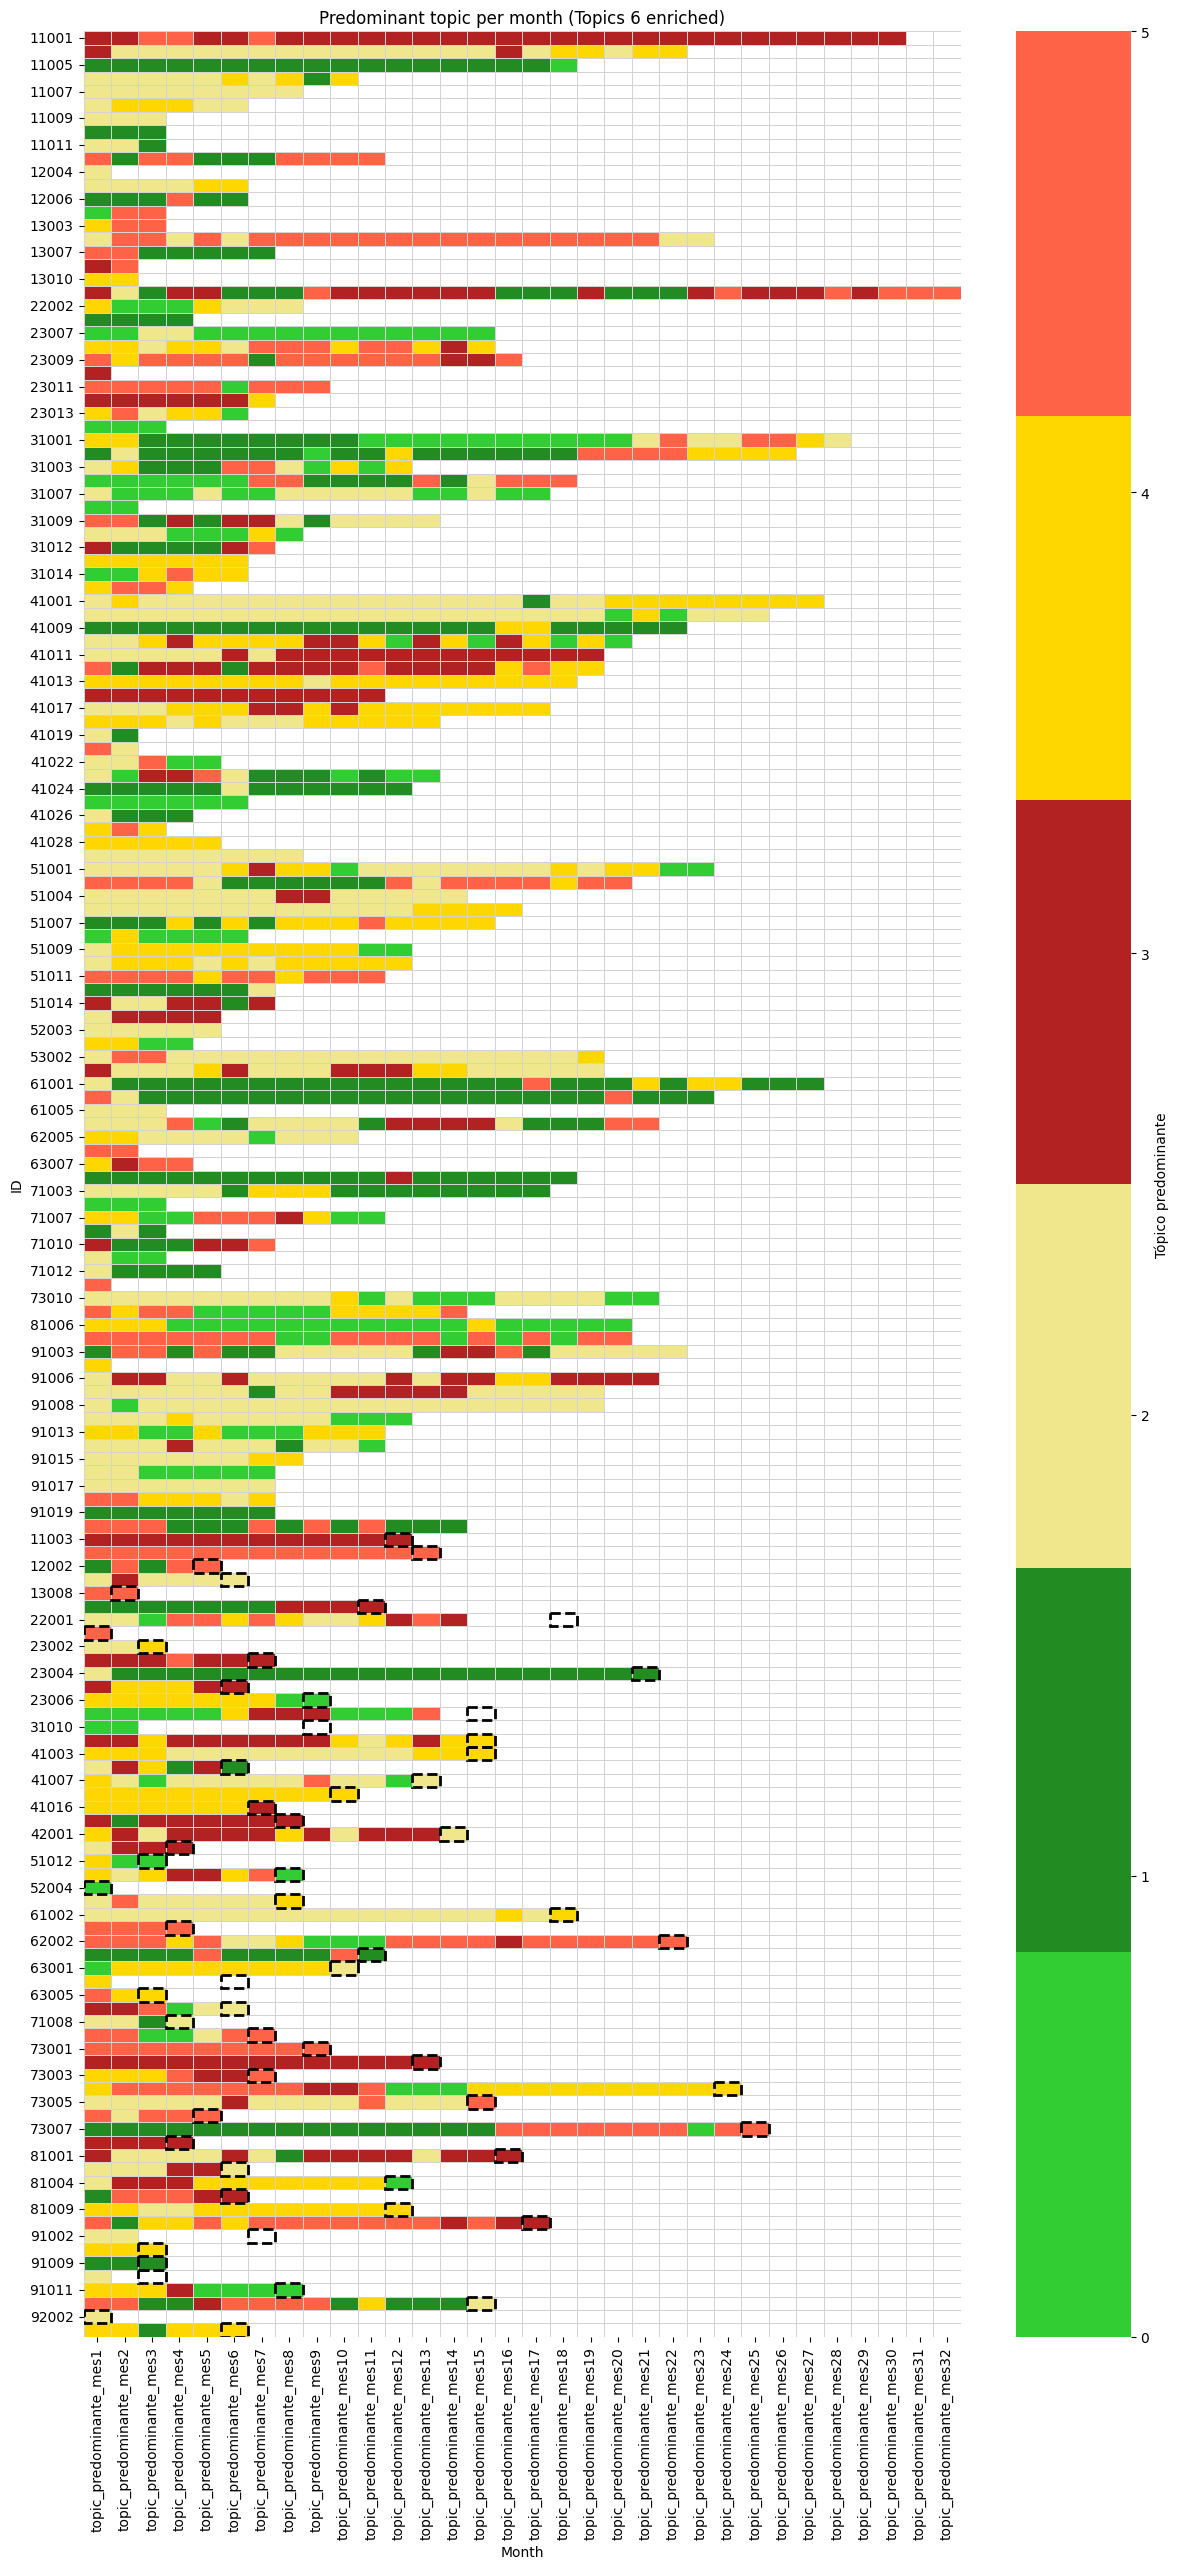

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------------
# 1 ·  Limpiar plot_df  →  reemplazar pd.NA  y convertir a float
# ------------------------------------------------------------------
n_topics=6

plot_df_clean = (
    plot_df #plot_df_filt 
    .replace({pd.NA: np.nan})        # paso crítico
    .apply(pd.to_numeric, errors='coerce')  # asegura float
) 


'''plot_df_clean=plot_df_filt_clean
ordered_df=ordered_df_filt
'''

# ------------------------------------------------------------------
# 2 ·  Configurar colores discretos 0-5
# ------------------------------------------------------------------

topic_colors = {
    3: "#b22222",  # rojo fuego (topic 0)
    5: "#ff6347",  # rojo tomate (topic 5)

    1: "#228b22",  # verde bosque (topic 2)
    0: "#32cd32",  # verde lima (topic 4)

    4: "#ffd700",  # amarillo dorado (topic 1)
    2: "#f0e68c",  # amarillo khaki (topic 3)
}



color_list = [topic_colors[i] for i in sorted(topic_colors)]
cmap = ListedColormap(color_list)

# ------------------------------------------------------------------
# 3 ·  Dibujar figura  +  heatmap
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, len(plot_df_clean) * 0.15)) #plot_df_filt_clean

sns.heatmap(
    plot_df_clean, #plot_df_filt_clean
    cmap=cmap,
    vmin=0, vmax=len(color_list) - 1,   # 0-5
    linewidths=.5, linecolor='lightgray',
    cbar_kws={'label': 'Tópico predominante'},
    mask=plot_df_clean.isna(), #plot_df_filt_clean
    ax=ax
)

# ------------------------------------------------------------------
# 4 ·  Marcar la celda del evento
# ------------------------------------------------------------------
for i, row in ordered_df.iterrows():        # plot_df ordered_df_filt
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black',
                linewidth=2, linestyle='--'
            ))
            # ▸  si prefieres estrella, comenta el Rectangle y descomenta:
            # ax.text(mes_evento + 0.5, i + 0.5, '★',
            #         ha='center', va='center', color='black', fontsize=12)

# ------------------------------------------------------------------
# 5 ·  Etiquetas y mostrar
# ------------------------------------------------------------------
plt.title(f"Predominant topic per month (Topics {n_topics} enriched)")
plt.xlabel("Month")
plt.ylabel("ID")
plt.tight_layout()
plt.show()


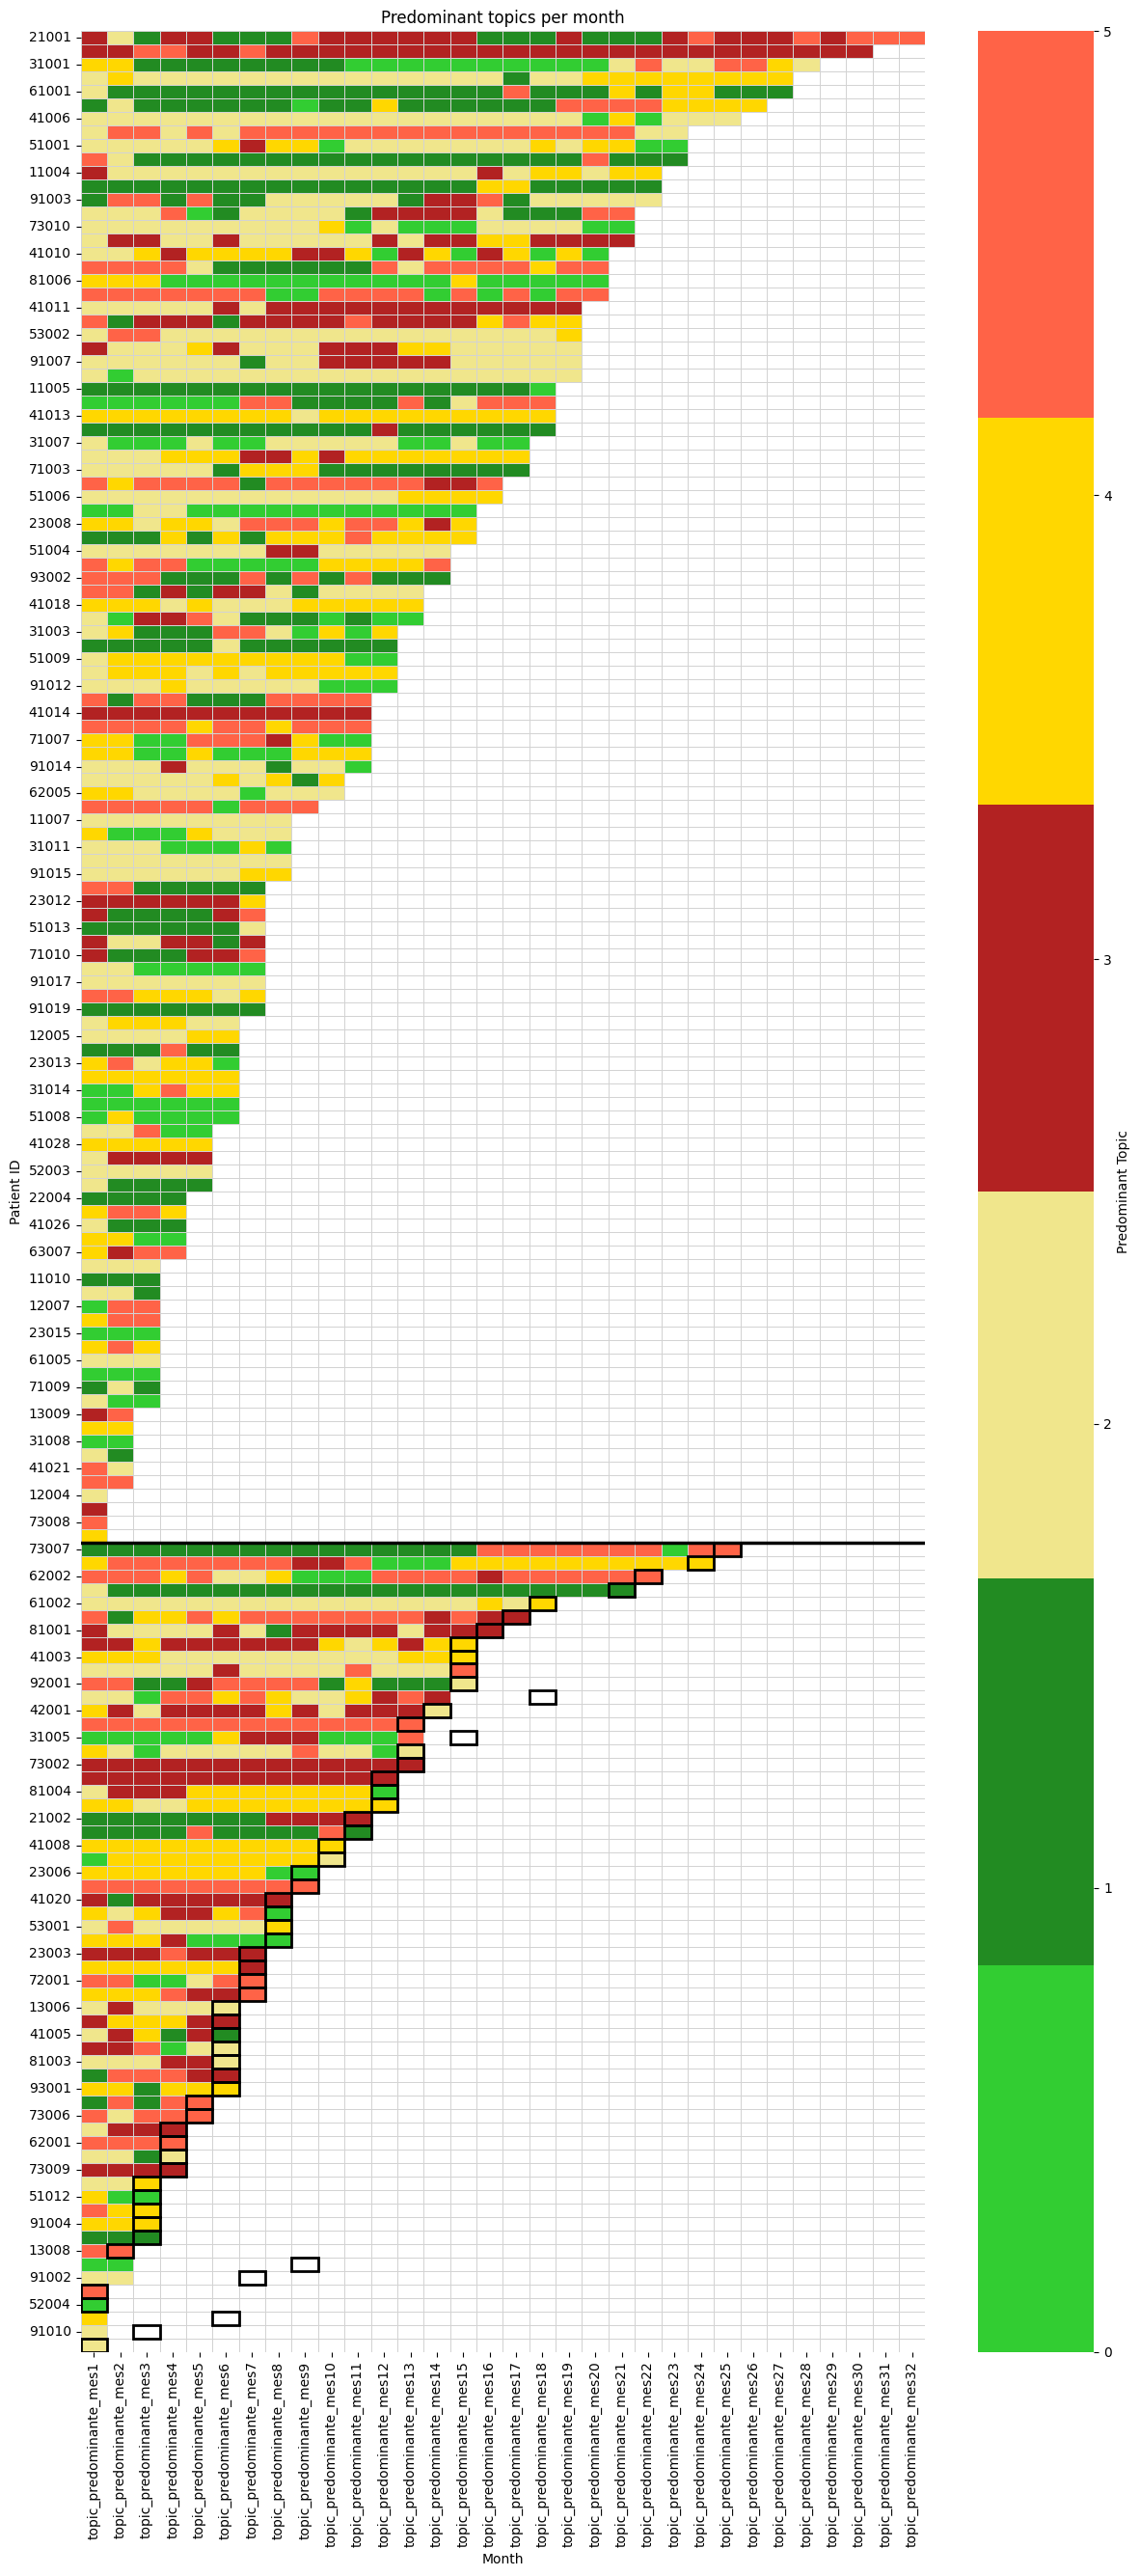

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------------
# 1 · Clean and Sort by Availability
# ------------------------------------------------------------------
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

# Calculate how many months of data each patient has
temp_df = ordered_df.copy()
temp_df['available_months'] = temp_df[topic_cols].notna().sum(axis=1)

# Sort: 
# 1st: Event (0 on top, 1 at bottom)
# 2nd: available_months (Descending: more months on top)
ordered_df_sorted = (
    temp_df
    .dropna(subset=topic_cols, how='all')
    .sort_values(by=['Event', 'available_months'], ascending=[True, False])
    .reset_index(drop=True)
)

# Prepare plot data
plot_df_clean = (
    ordered_df_sorted[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# ------------------------------------------------------------------
# 2 · Configure discrete colors
# ------------------------------------------------------------------
n_topics = 6
topic_colors = {
    3: "#b22222", # Red
    5: "#ff6347", # Tomato
    1: "#228b22", # Forest Green
    0: "#32cd32", # Lime Green
    4: "#ffd700", # Gold
    2: "#f0e68c", # Khaki
}
color_list = [topic_colors[i] for i in sorted(topic_colors)]
cmap = ListedColormap(color_list)

# ------------------------------------------------------------------
# 3 · Draw Figure + Heatmap
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, len(plot_df_clean) * 0.15 + 1))

sns.heatmap(
    plot_df_clean,
    cmap=cmap,
    vmin=0, vmax=len(color_list) - 1,
    linewidths=.5, linecolor='lightgray',
    cbar_kws={'label': 'Predominant Topic'},
    mask=plot_df_clean.isna(),
    ax=ax
)

# ------------------------------------------------------------------
# 4 · Mark the Event Cells
# ------------------------------------------------------------------
for i, row in ordered_df_sorted.iterrows():
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black',
                linewidth=2, linestyle='-'
            ))

# ------------------------------------------------------------------
# 5 · Labels and Visual Separator
# ------------------------------------------------------------------
n_no_pd = len(ordered_df_sorted[ordered_df_sorted['Event'] == 0])
ax.axhline(n_no_pd, color='black', linewidth=2.5)

plt.title(f"Predominant topics per month")
plt.xlabel("Month")
plt.ylabel("Patient ID")
plt.tight_layout()
plt.show()

Gráfico guardado como 'heatmap_hypertopics.svg'


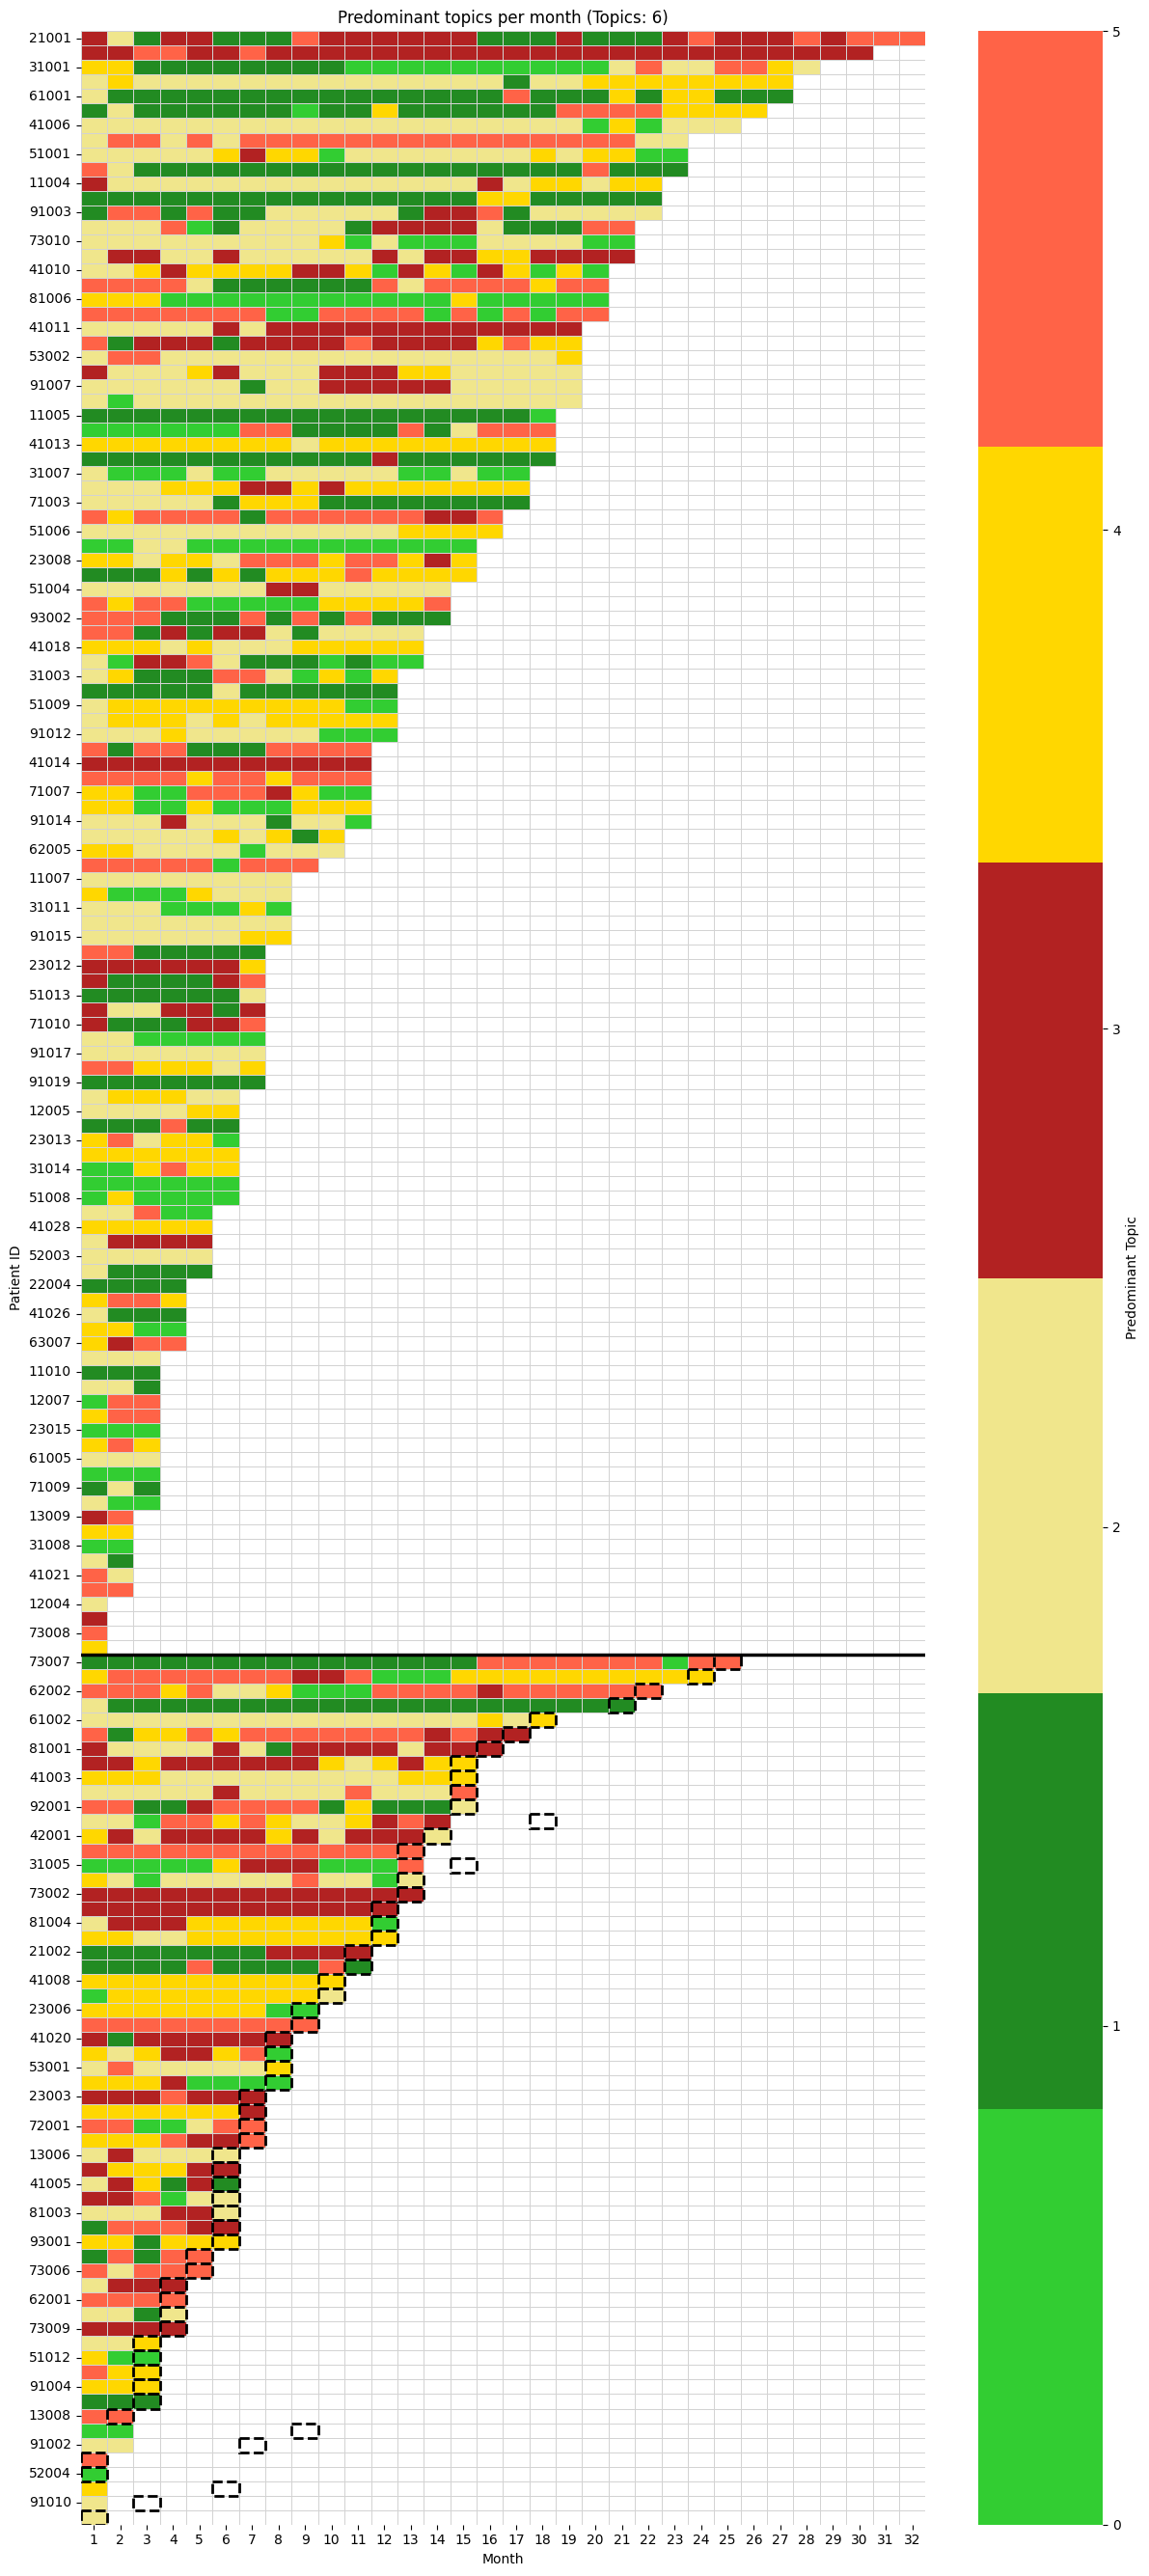

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------------
# 1 · Clean and Sort by Availability
# ------------------------------------------------------------------
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

# Calculate completeness of data for sorting
temp_df = ordered_df.copy()
temp_df['available_months'] = temp_df[topic_cols].notna().sum(axis=1)

# Sort: Event 0 first, then by available months (Descending)
ordered_df_sorted = (
    temp_df
    .dropna(subset=topic_cols, how='all')
    .sort_values(by=['Event', 'available_months'], ascending=[True, False])
    .reset_index(drop=True)
)

# Prepare plot data
plot_df_clean = (
    ordered_df_sorted[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# ------------------------------------------------------------------
# 2 · Configure discrete colors
# ------------------------------------------------------------------
n_topics = 6
topic_colors = {
    3: "#b22222", # Red (Topic 3)
    5: "#ff6347", # Tomato (Topic 5)
    1: "#228b22", # Forest Green (Topic 1)
    0: "#32cd32", # Lime Green (Topic 0)
    4: "#ffd700", # Gold (Topic 4)
    2: "#f0e68c", # Khaki (Topic 2)
}
color_list = [topic_colors[i] for i in sorted(topic_colors)]
cmap = ListedColormap(color_list)

# ------------------------------------------------------------------
# 3 · Draw Figure + Heatmap
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, len(plot_df_clean) * 0.15 + 1))

# Clean X-axis: extract ONLY the digits from column names
x_axis_numbers = [re.findall(r'\d+', col)[-1] for col in topic_cols]

sns.heatmap(
    plot_df_clean,
    cmap=cmap,
    vmin=0, vmax=len(color_list) - 1,
    linewidths=.5, linecolor='lightgray',
    xticklabels=x_axis_numbers,  # Pure numbers 1, 2, 3...
    cbar_kws={'label': 'Predominant Topic'},
    mask=plot_df_clean.isna(),
    ax=ax
)

# ------------------------------------------------------------------
# 4 · Mark the Event Cells
# ------------------------------------------------------------------
for i, row in ordered_df_sorted.iterrows():
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black',
                linewidth=2, linestyle='--'
            ))

# ------------------------------------------------------------------
# 5 · Labels and Visual Separator
# ------------------------------------------------------------------
n_no_pd = len(ordered_df_sorted[ordered_df_sorted['Event'] == 0])
ax.axhline(n_no_pd, color='black', linewidth=2.5)

plt.title(f"Predominant topics per month (Topics: {n_topics})")
plt.xlabel("Month")
plt.ylabel("Patient ID")
plt.tight_layout()


# -------------------------------------------
# 7 · Save as SVG (NUEVO)
# -------------------------------------------
# Esto guarda el gráfico como archivo vectorial escalable
save_dir=os.path.join(module_path, "2nd_phase", "results", "topic_plots")
save_path = os.path.join(save_dir, f"heatmap_topics.svg")
plt.savefig(save_path, format='svg', bbox_inches='tight')

print("Gráfico guardado como 'heatmap_hypertopics.svg'")

plt.show()

In [28]:
df_day_id=df_day[df_day['id']==91010]
embedd=df_day_id['embedding_ids']
print(embedd)
# Si 'embedd' es la Serie que mostraste:
# Accedemos al primer elemento de la serie (.iloc[0]) y calculamos su longitud
longitud = len(embedd.iloc[0])

print(f"La longitud de la lista de embedding_ids para el ID 91009 es: {longitud}")

161    [156, 240, 247, 188, 43, 43, 131, 116, 72, 3, ...
Name: embedding_ids, dtype: object
La longitud de la lista de embedding_ids para el ID 91009 es: 115


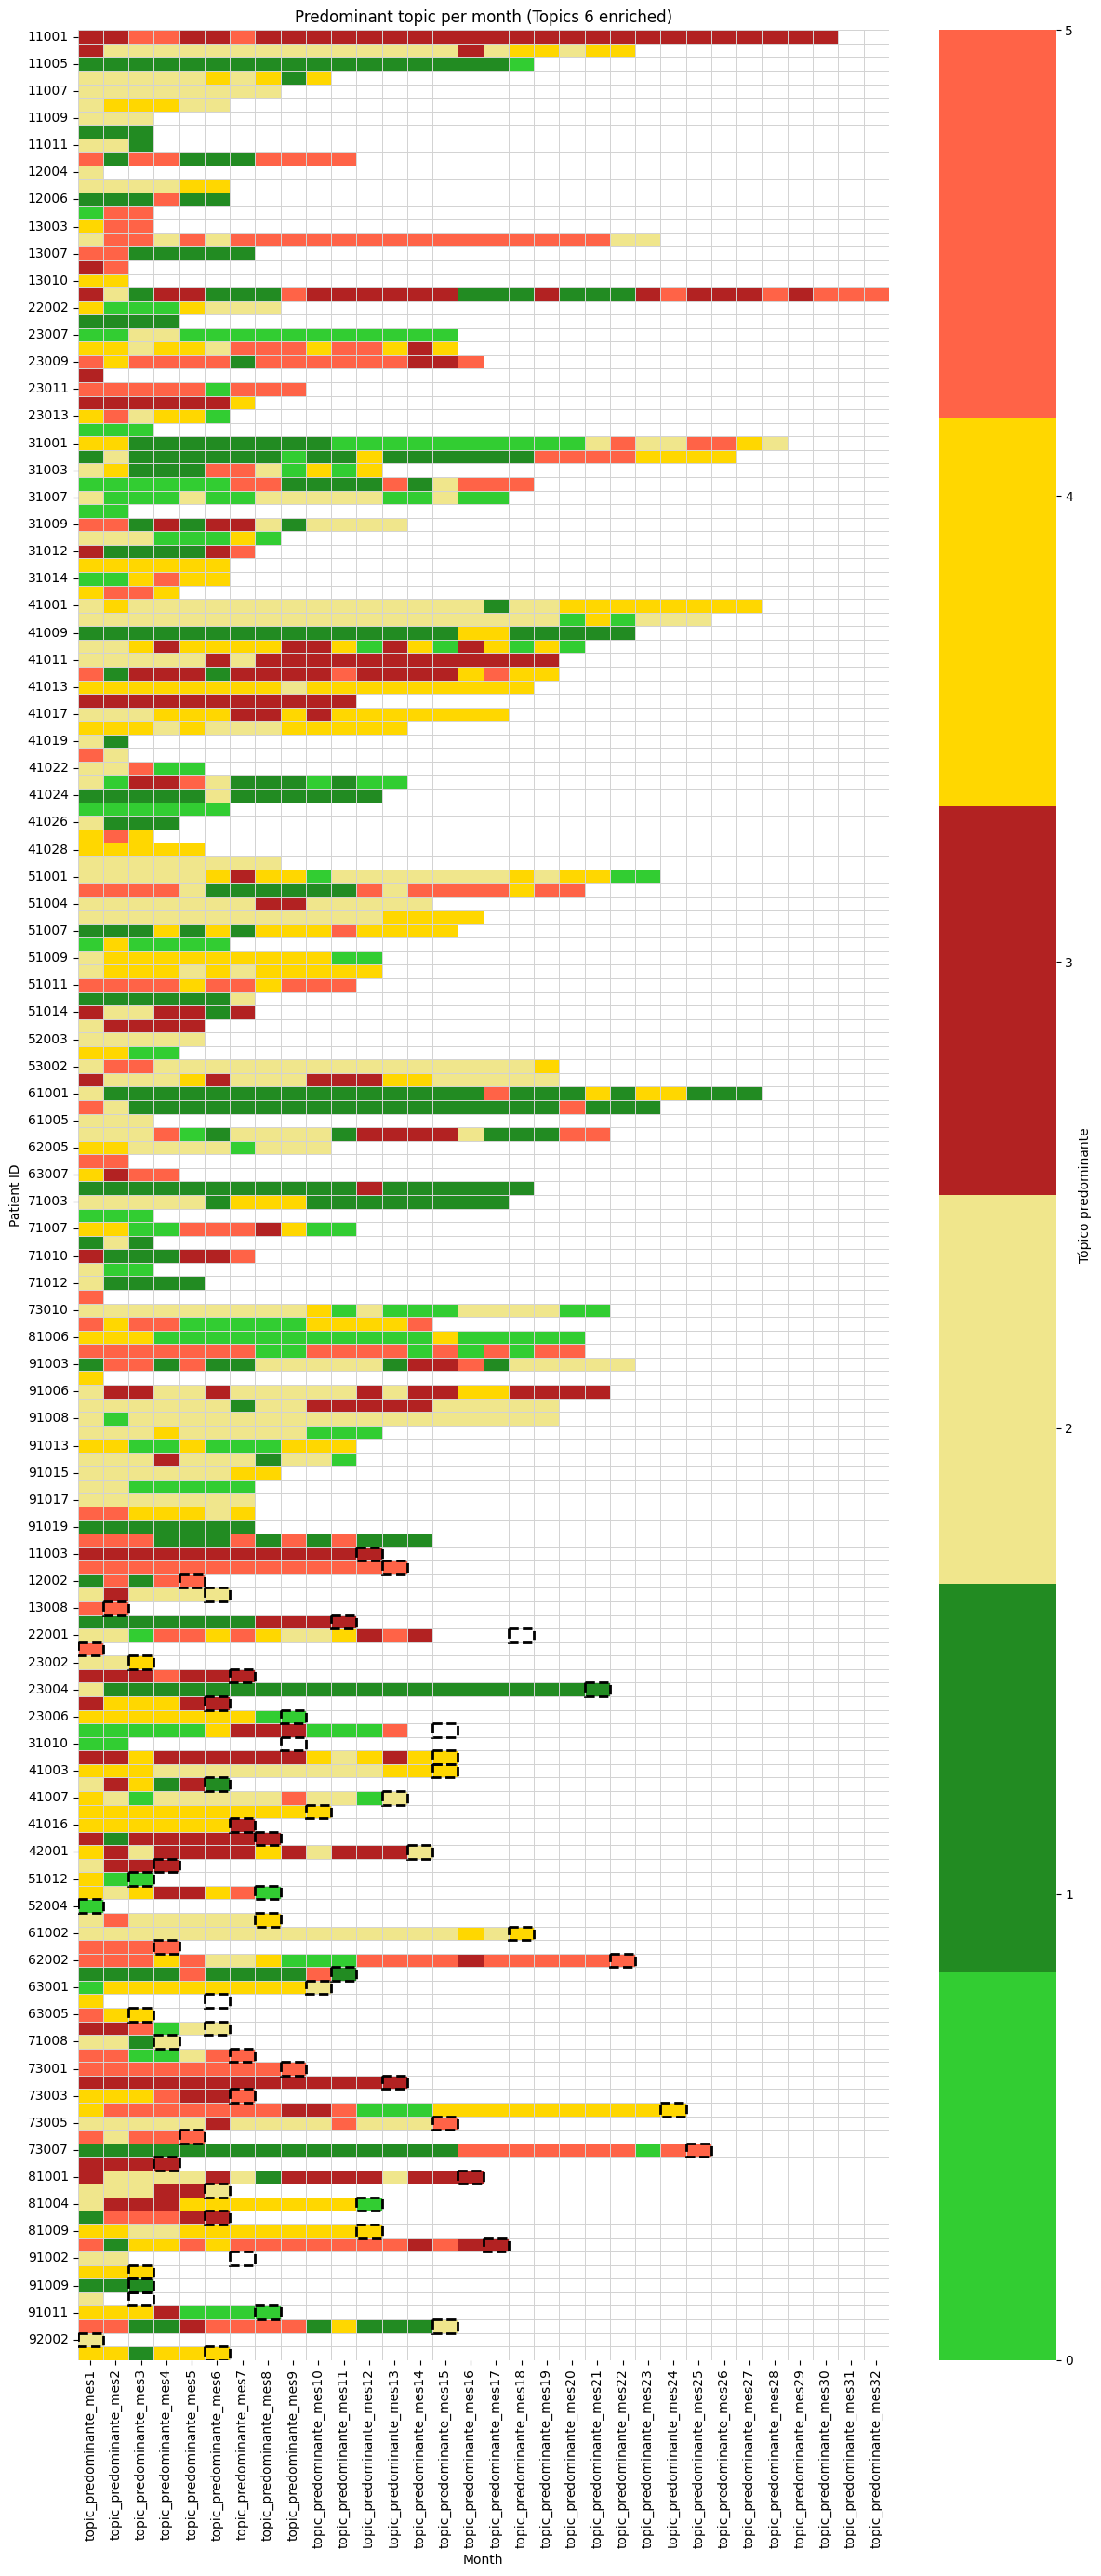

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------------
# 1 · Limpiar y Sincronizar (Paso clave para evitar desplazamientos)
# ------------------------------------------------------------------
# Filtramos primero ordered_df para quitar los pacientes que no tienen datos (NaN en todo)
# Esto asegura que el heatmap y el bucle de eventos vayan a la par.
ordered_df_clean = ordered_df.dropna(subset=topic_cols, how='all').reset_index(drop=True)

# Creamos el plot_df basado en ese df ya limpio
plot_df_clean = (
    ordered_df_clean[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# ------------------------------------------------------------------
# 2 · Configurar colores discretos
# ------------------------------------------------------------------
topic_colors = {
    3: "#b22222", 5: "#ff6347", # Rojos
    1: "#228b22", 0: "#32cd32", # Verdes
    4: "#ffd700", 2: "#f0e68c", # Amarillos
}
color_list = [topic_colors[i] for i in sorted(topic_colors)]
cmap = ListedColormap(color_list)

# ------------------------------------------------------------------
# 3 · Dibujar Heatmap
# ------------------------------------------------------------------
# Ajustamos el tamaño según el número REAL de pacientes que quedan
fig, ax = plt.subplots(figsize=(12, len(plot_df_clean) * 0.15 + 2))

sns.heatmap(
    plot_df_clean,
    cmap=cmap,
    vmin=0, vmax=len(color_list) - 1,
    linewidths=.5, linecolor='lightgray',
    cbar_kws={'label': 'Tópico predominante'},
    mask=plot_df_clean.isna(),
    ax=ax
)

# ------------------------------------------------------------------
# 4 · Marcar el evento (SIN DESPLAZAMIENTOS)
# ------------------------------------------------------------------
# Usamos enumerate para obtener la posición vertical 'idx' (0, 1, 2...) 
# independientemente del ID del paciente.
for idx, (_, row) in enumerate(ordered_df_clean.iterrows()):
    if row['Event'] == 1:
        # Calculamos el mes (posición X)
        mes_evento = int(row['t_evento_eb2'] // 30)
        
        # Solo dibujamos si el mes cae dentro del rango visible del heatmap
        if 0 <= mes_evento < len(topic_cols):
            # idx es la posición y (fila), mes_evento es la posición x (columna)
            ax.add_patch(plt.Rectangle(
                (mes_evento, idx), 1, 1,
                fill=False, edgecolor='black',
                linewidth=2, linestyle='--'
            ))

# ------------------------------------------------------------------
# 5 · Etiquetas y mostrar
# ------------------------------------------------------------------
plt.title(f"Predominant topic per month (Topics {n_topics} enriched)")
plt.xlabel("Month")
plt.ylabel("Patient ID")
plt.tight_layout()
plt.show()

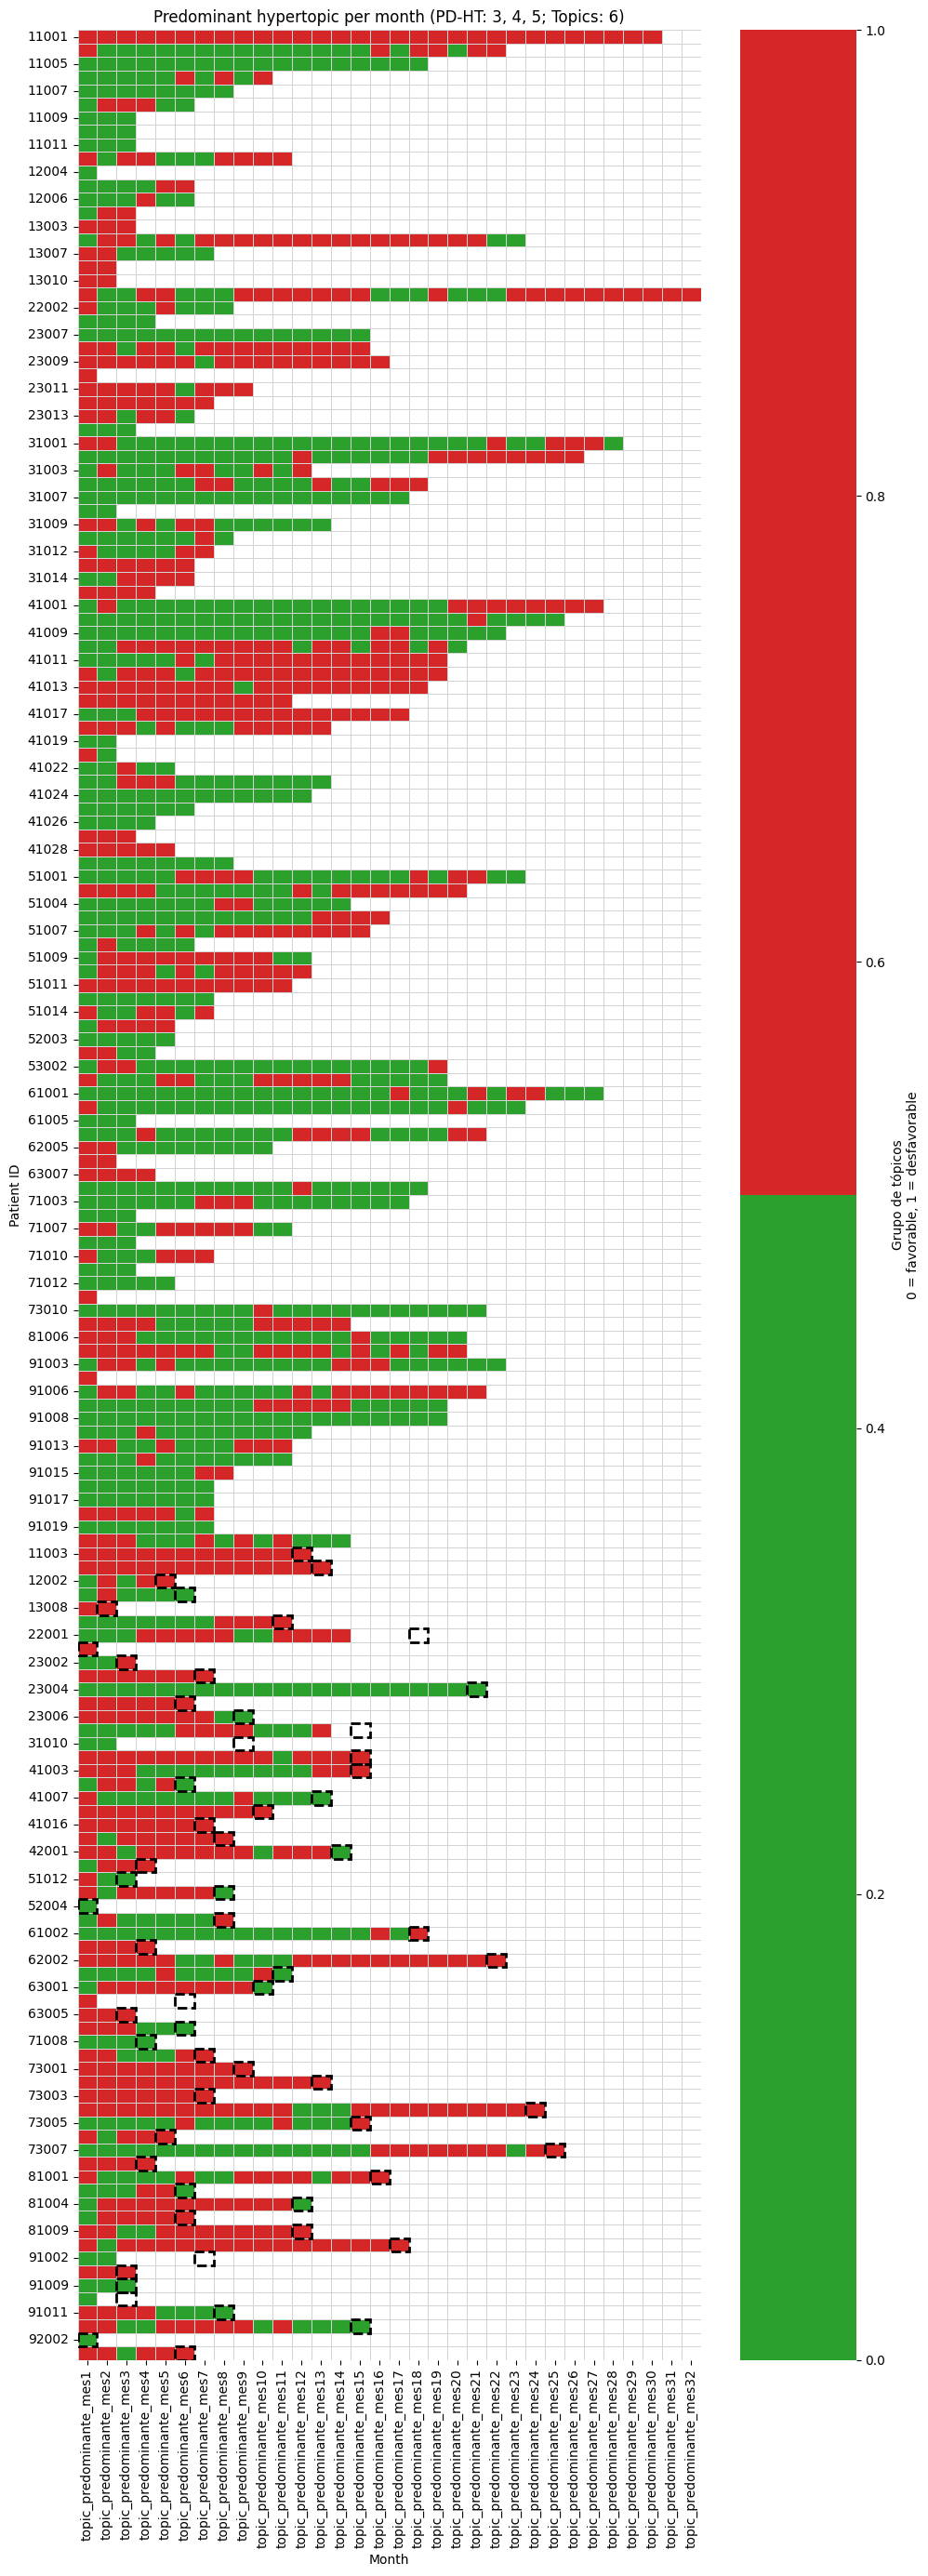

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# -------------------------------------------
# 1 · Sincronizar y Limpiar
# -------------------------------------------
n_topics = 6
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

# Filtramos los pacientes que no tienen ningún dato en los meses (NaN completo)
# Esto asegura que el heatmap y el bucle de eventos tengan el mismo número de filas.
ordered_df_clean = ordered_df.dropna(subset=topic_cols, how='all').reset_index(drop=True)

plot_df_clean = (
    ordered_df_clean[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# -------------------------------------------
# 2 · Mapear tópicos → grupos (0: favorable, 1: desfavorable)
# -------------------------------------------
group_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
plot_df_grouped = plot_df_clean.replace(group_map)

# -------------------------------------------
# 3 · Colores para los dos grupos
# -------------------------------------------
group_colors = ['#2ca02c',   # verde para grupo 0
                '#d62728']   # rojo para grupo 1
cmap_groups = ListedColormap(group_colors)

# -------------------------------------------
# 4 · Dibujar figura y heatmap
# -------------------------------------------
# Ajustamos el alto de la figura al número real de pacientes limpios
fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15 + 2))

sns.heatmap(
    plot_df_grouped,
    cmap=cmap_groups,
    vmin=0, vmax=1,
    linewidths=.5, linecolor='lightgray',
    mask=plot_df_grouped.isna(),
    cbar_kws={'label': 'Grupo de tópicos\n0 = favorable, 1 = desfavorable'},
    ax=ax
)

# -------------------------------------------
# 5 · Marcar la celda del evento (Sincronizado)
# -------------------------------------------
# Usamos enumerate sobre el DF limpio para que 'idx' sea la posición vertical real
for idx, (_, row) in enumerate(ordered_df_clean.iterrows()):
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        # Comprobamos que el mes esté dentro de las columnas que estamos dibujando
        if 0 <= mes_evento < len(topic_cols):
            # idx es la fila (Y), mes_evento es la columna (X)
            ax.add_patch(plt.Rectangle(
                (mes_evento, idx), 1, 1,
                fill=False, edgecolor='black', linewidth=2, linestyle='--'
            ))

# -------------------------------------------
# 6 · Etiquetas finales
# -------------------------------------------
plt.title(f"Predominant hypertopic per month (PD-HT: 3, 4, 5; Topics: {n_topics})")
plt.xlabel("Month")
plt.ylabel("Patient ID")
plt.tight_layout()
plt.show()

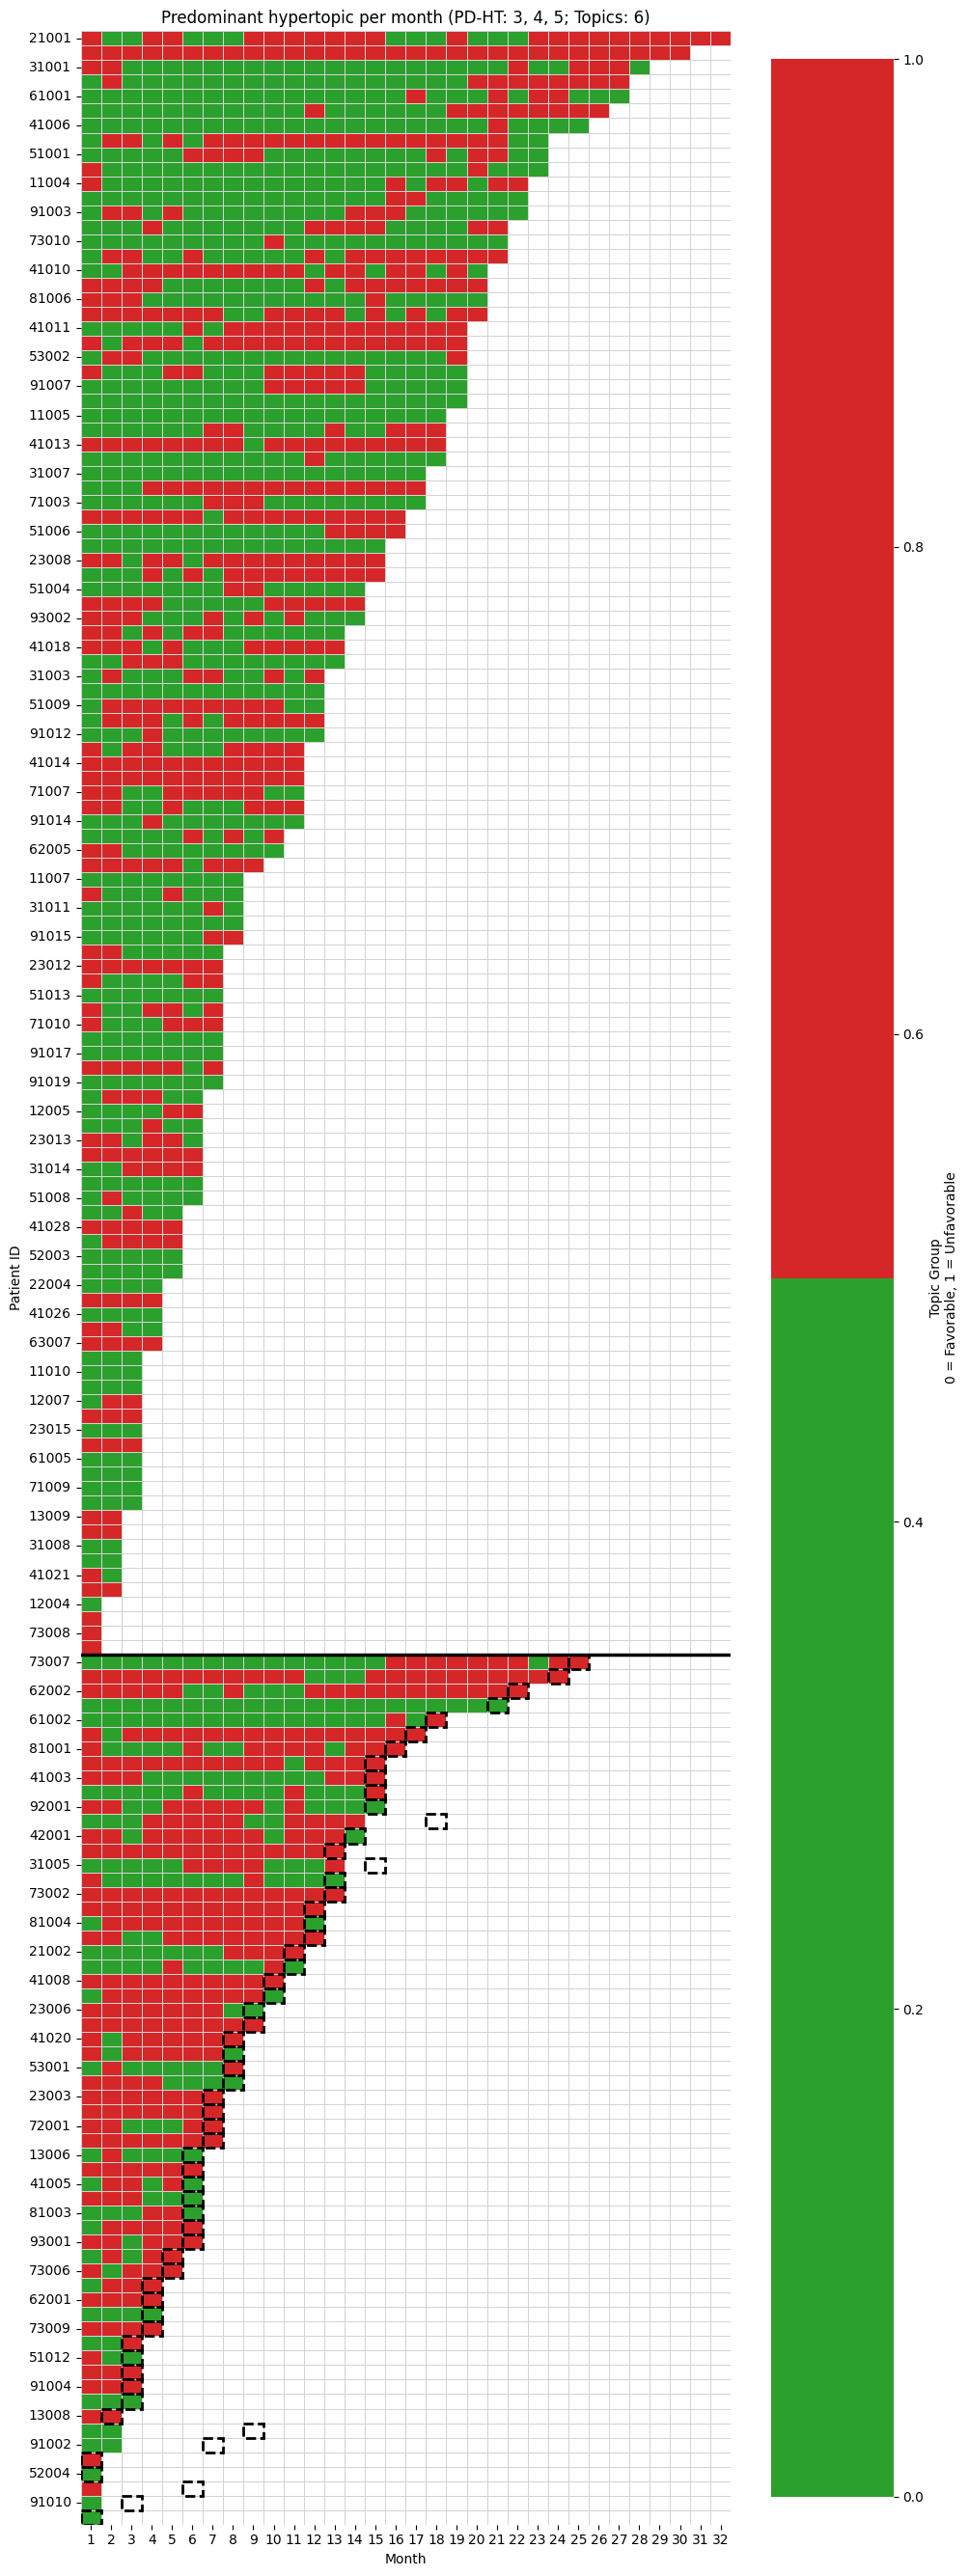

Gráfico guardado como 'heatmap_hypertopics.svg'


<Figure size 640x480 with 0 Axes>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import re  # Importamos para limpiar el texto

# -------------------------------------------
# 1 · Sort and Clean Data (by Availability)
# -------------------------------------------
# Nota: Asumo que 'ordered_df' está definido previamente en tu entorno
n_topics = 6
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

temp_df = ordered_df.copy()
temp_df['available_months'] = temp_df[topic_cols].notna().sum(axis=1)

ordered_df_sorted = (
    temp_df
    .dropna(subset=topic_cols, how='all')
    .sort_values(by=['Event', 'available_months'], ascending=[True, False])
    .reset_index(drop=True)
)

plot_df_clean = (
    ordered_df_sorted[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# -------------------------------------------
# 2 · Map topics → groups (Hypertopics)
# -------------------------------------------
group_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
plot_df_grouped = plot_df_clean.replace(group_map)

# -------------------------------------------
# 3 · Colors
# -------------------------------------------
group_colors = ['#2ca02c', '#d62728']
cmap_groups = ListedColormap(group_colors)

# -------------------------------------------
# 4 · Draw figure and heatmap
# -------------------------------------------
fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15 + 1))

# --- CAMBIO AQUÍ: Extraer solo números del nombre de la columna ---
x_axis_numbers = [re.findall(r'\d+', col)[-1] for col in topic_cols]

sns.heatmap(
    plot_df_grouped,
    cmap=cmap_groups,
    vmin=0, vmax=1,
    linewidths=.5, linecolor='lightgray',
    mask=plot_df_grouped.isna(),
    xticklabels=x_axis_numbers,  # <--- Solo números (1, 2, 3...)
    cbar_kws={'label': 'Topic Group\n0 = Favorable, 1 = Unfavorable'},
    ax=ax
)

# -------------------------------------------
# 5 · Mark the Event Cells
# -------------------------------------------
for i, row in ordered_df_sorted.iterrows():
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black', linewidth=2, linestyle='--'
            ))

n_no_pd = len(ordered_df_sorted[ordered_df_sorted['Event'] == 0])
ax.axhline(n_no_pd, color='black', linewidth=2.5)

# -------------------------------------------
# 6 · Final Labels
# -------------------------------------------
plt.title(f"Predominant hypertopic per month (PD-HT: 3, 4, 5; Topics: {n_topics})")
plt.xlabel("Month")
plt.ylabel("Patient ID")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 7 · Save as SVG (NUEVO)
# -------------------------------------------
# Esto guarda el gráfico como archivo vectorial escalable
save_dir=os.path.join(module_path, "2nd_phase", "results", "topic_plots")
save_path = os.path.join(save_dir, f"heatmap_hypertopics_345.svg")
plt.savefig(save_path, format='svg', bbox_inches='tight')

print("Gráfico guardado como 'heatmap_hypertopics.svg'")

# -------------------------------------------
# 8 · Show plot
# -------------------------------------------
plt.show()

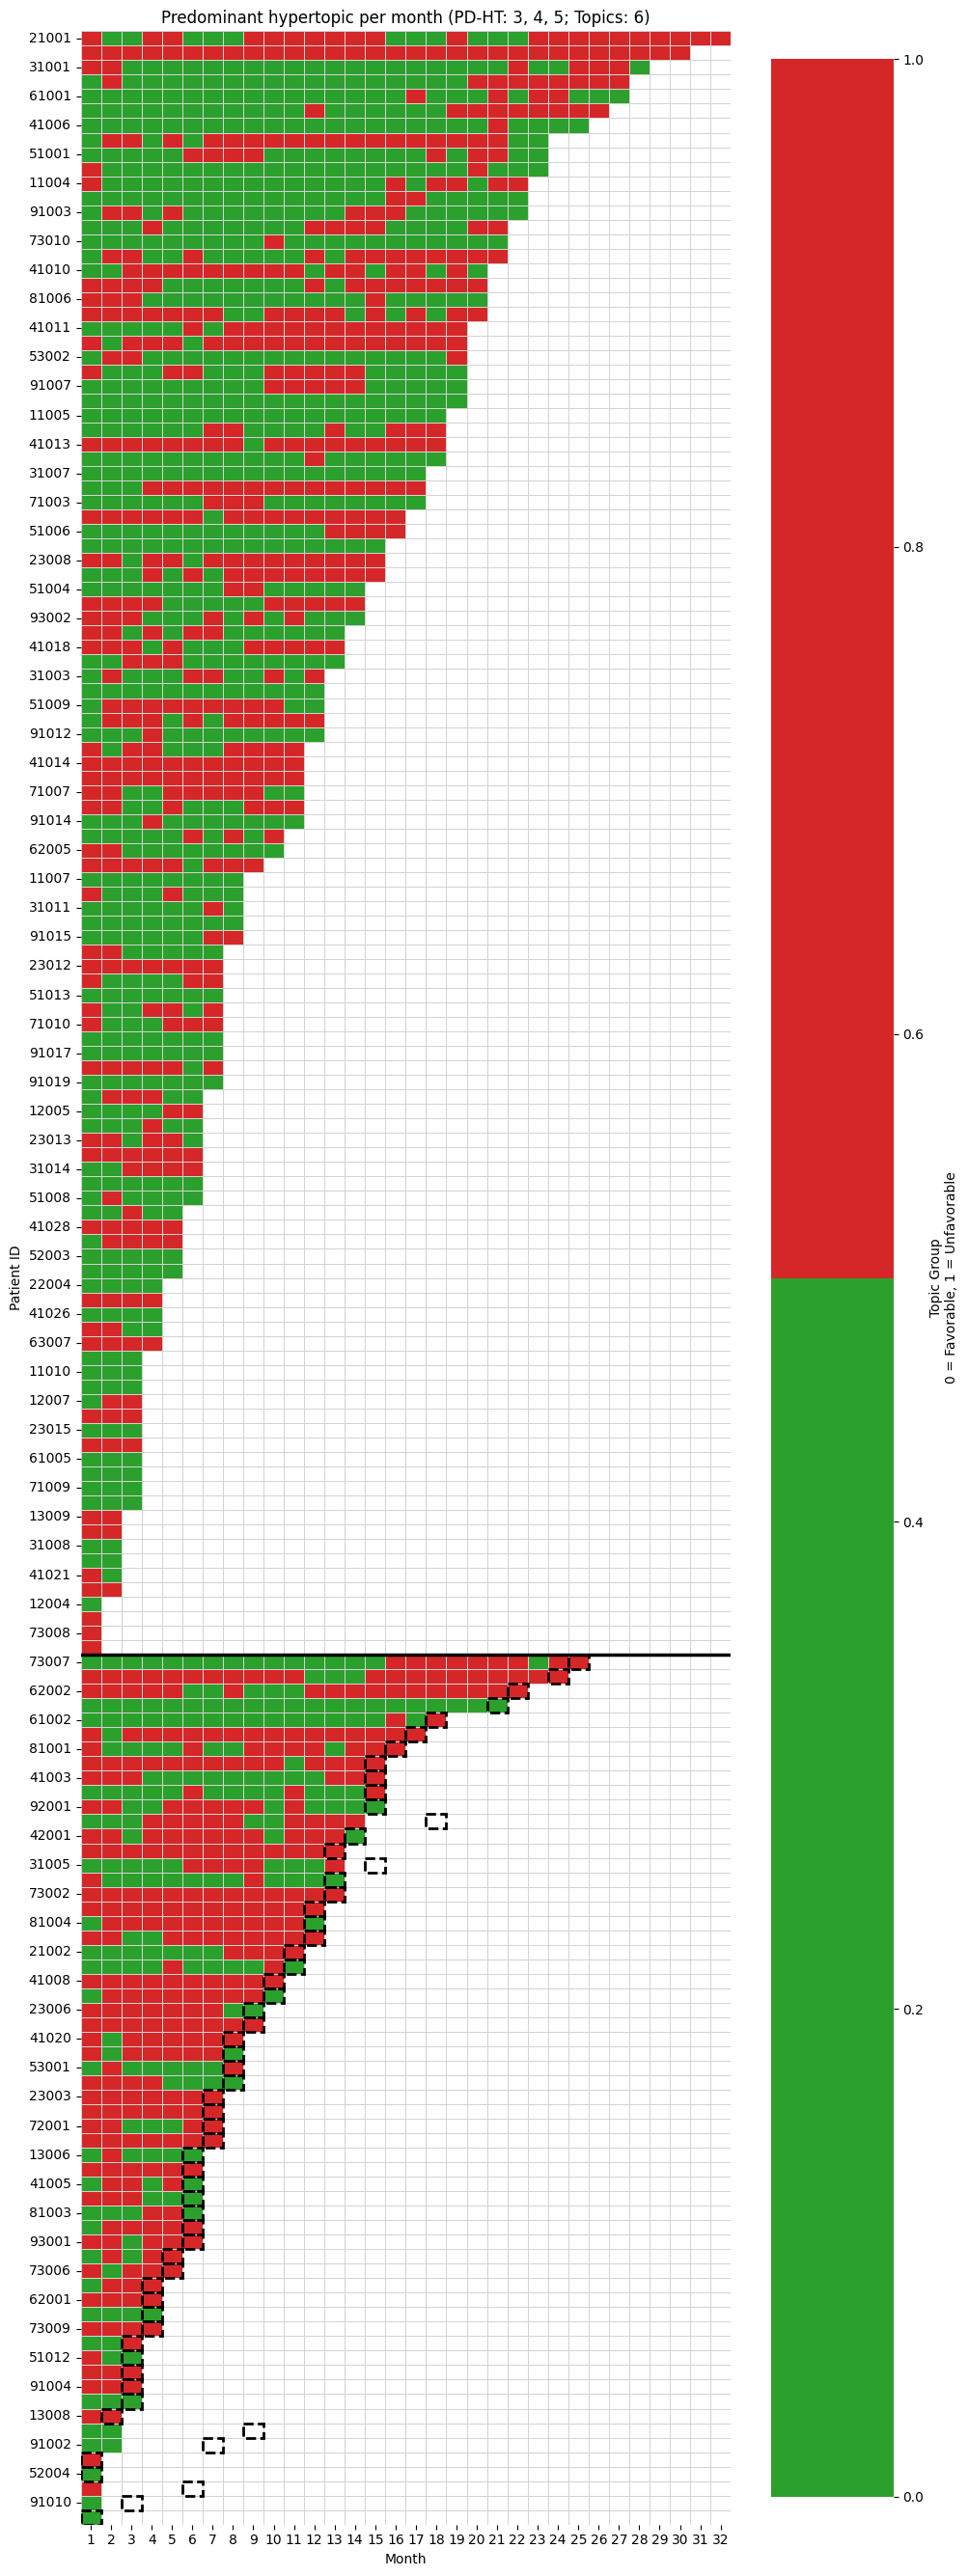

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import re  # Importamos para limpiar el texto

# -------------------------------------------
# 1 · Sort and Clean Data (by Availability)
# -------------------------------------------
n_topics = 6
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

temp_df = ordered_df.copy()
temp_df['available_months'] = temp_df[topic_cols].notna().sum(axis=1)

ordered_df_sorted = (
    temp_df
    .dropna(subset=topic_cols, how='all')
    .sort_values(by=['Event', 'available_months'], ascending=[True, False])
    .reset_index(drop=True)
)

plot_df_clean = (
    ordered_df_sorted[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# -------------------------------------------
# 2 · Map topics → groups (Hypertopics)
# -------------------------------------------
group_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
plot_df_grouped = plot_df_clean.replace(group_map)

# -------------------------------------------
# 3 · Colors
# -------------------------------------------
group_colors = ['#2ca02c', '#d62728']
cmap_groups = ListedColormap(group_colors)

# -------------------------------------------
# 4 · Draw figure and heatmap
# -------------------------------------------
fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15 + 1))

# --- CAMBIO AQUÍ: Extraer solo números del nombre de la columna ---
# Esto busca cualquier número en el nombre, ignorando "mes" o "topic"
x_axis_numbers = [re.findall(r'\d+', col)[-1] for col in topic_cols]

sns.heatmap(
    plot_df_grouped,
    cmap=cmap_groups,
    vmin=0, vmax=1,
    linewidths=.5, linecolor='lightgray',
    mask=plot_df_grouped.isna(),
    xticklabels=x_axis_numbers,  # <--- Solo números (1, 2, 3...)
    cbar_kws={'label': 'Topic Group\n0 = Favorable, 1 = Unfavorable'},
    ax=ax
)

# -------------------------------------------
# 5 · Mark the Event Cells
# -------------------------------------------
for i, row in ordered_df_sorted.iterrows():
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black', linewidth=2, linestyle='--'
            ))

n_no_pd = len(ordered_df_sorted[ordered_df_sorted['Event'] == 0])
ax.axhline(n_no_pd, color='black', linewidth=2.5)

# -------------------------------------------
# 6 · Final Labels
# -------------------------------------------
plt.title(f"Predominant hypertopic per month (PD-HT: 3, 4, 5; Topics: {n_topics})")
plt.xlabel("Month")
plt.ylabel("Patient ID")
plt.tight_layout()
plt.show()

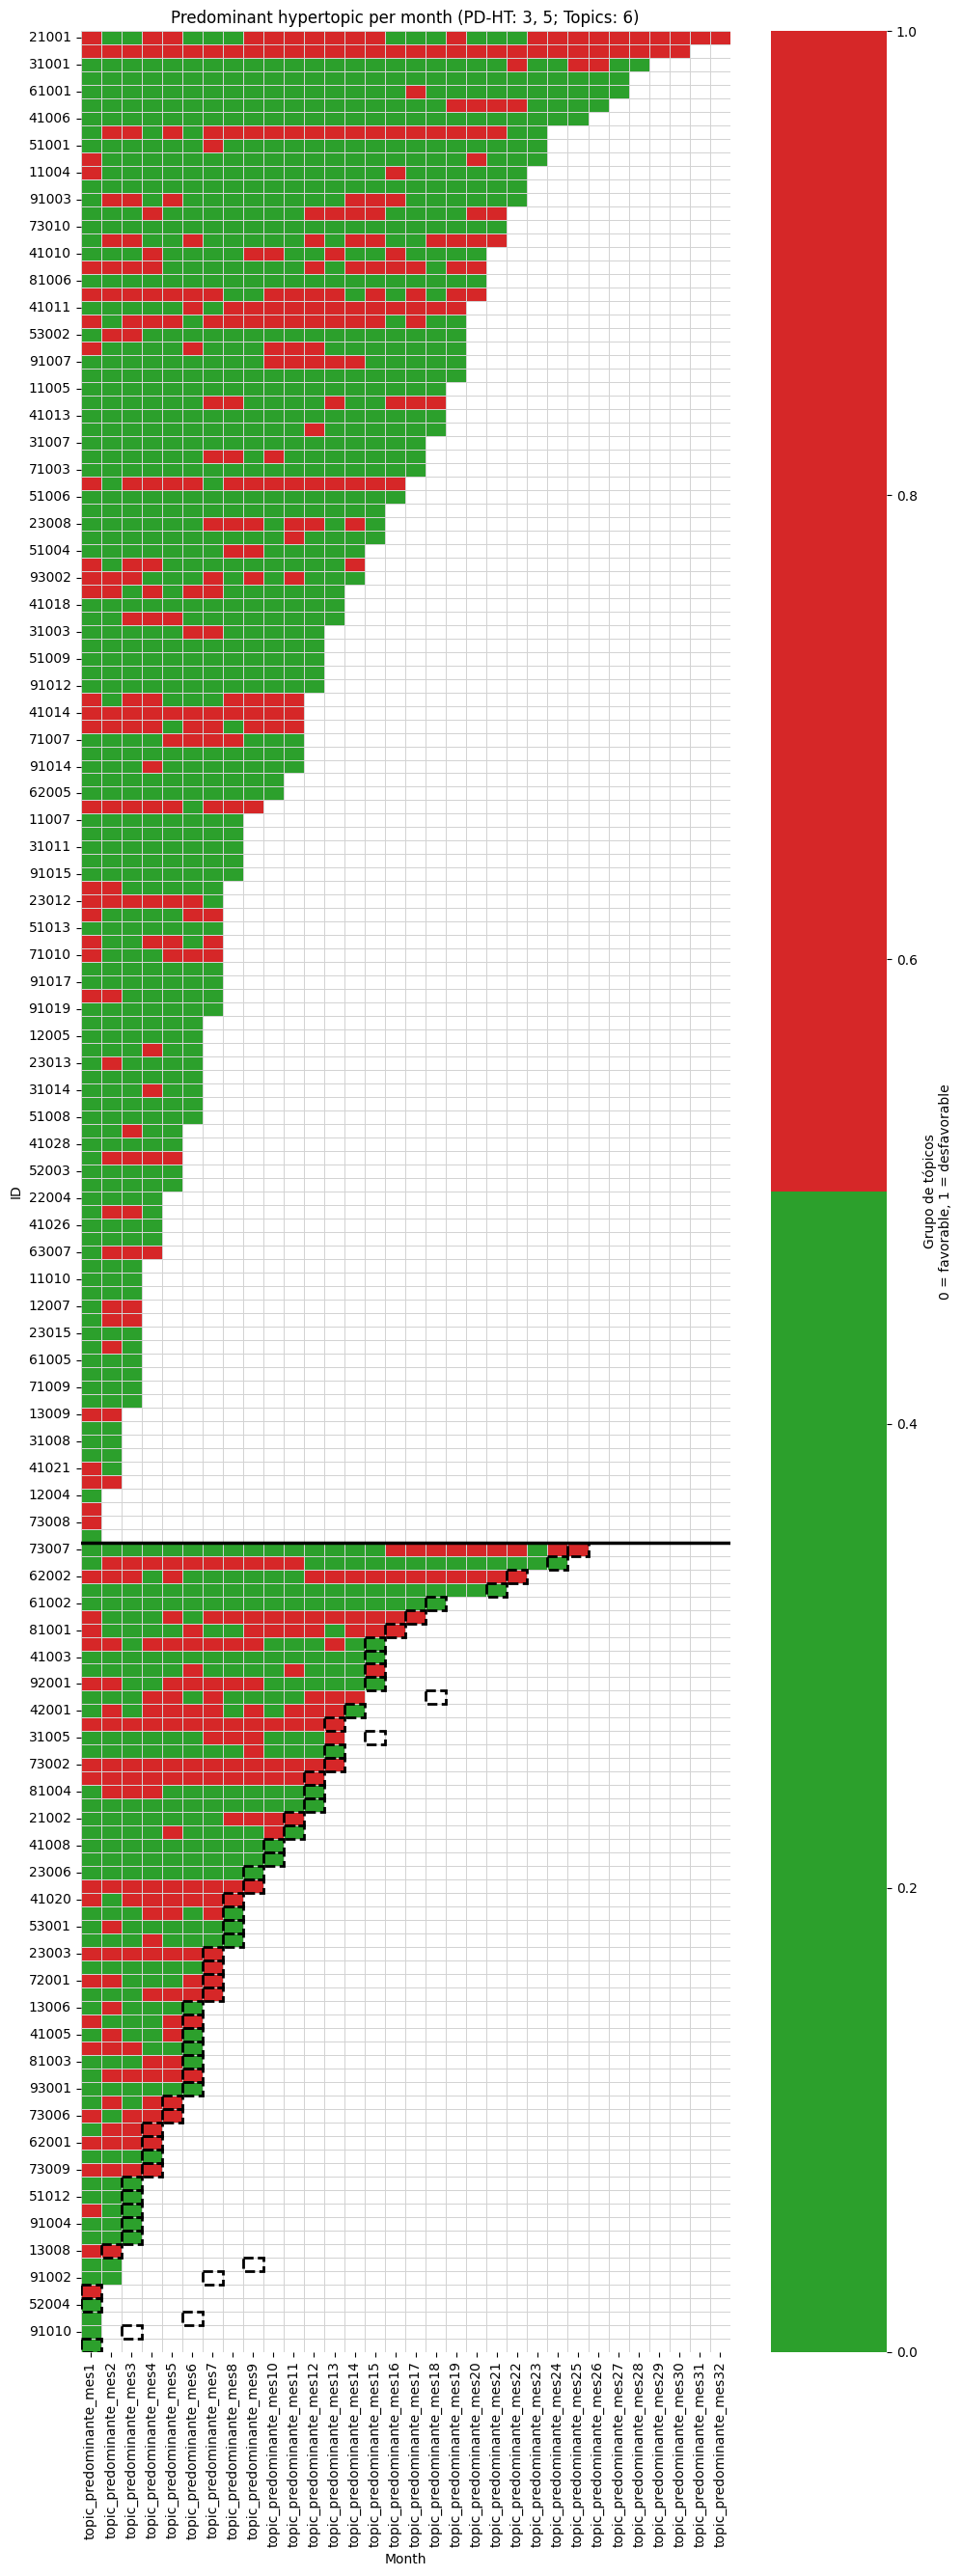

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# -------------------------------------------
# 1 · Sort and Clean Data (by Availability)
# -------------------------------------------
n_topics = 6
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_mes')]

# Count how many months of data each patient has
temp_df = ordered_df.copy()
temp_df['available_months'] = temp_df[topic_cols].notna().sum(axis=1)

# Sort: No-PD (0) top, PD (1) bottom. Within groups, most data (available_months) first.
ordered_df_sorted = (
    temp_df
    .dropna(subset=topic_cols, how='all')
    .sort_values(by=['Event', 'available_months'], ascending=[True, False])
    .reset_index(drop=True)
)

# Prepare the cleaned plot data
plot_df_clean = (
    ordered_df_sorted[['id'] + topic_cols]
    .set_index('id')
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# -------------------------------------------
# 2 · Map topics → groups (Hypertopics)
# -------------------------------------------
group_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 0, 5: 1}
plot_df_grouped = plot_df_clean.replace(group_map)

# -------------------------------------------
# 3 · Colors for the two groups
# -------------------------------------------
group_colors = ['#2ca02c',   # Green for Group 0 (Favorable)
                '#d62728']   # Red for Group 1 (Unfavorable)
cmap_groups = ListedColormap(group_colors)

# -------------------------------------------
# 4 · Draw figure and heatmap
# -------------------------------------------
fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15 + 1))

sns.heatmap(
    plot_df_grouped,
    cmap=cmap_groups,
    vmin=0, vmax=1,
    linewidths=.5, linecolor='lightgray',
    mask=plot_df_grouped.isna(),
    cbar_kws={'label': 'Grupo de tópicos\n0 = favorable, 1 = desfavorable'},
    ax=ax
)

# -------------------------------------------
# 5 · Mark the Event Cells (Synchronized)
# -------------------------------------------
for i, row in ordered_df_sorted.iterrows():
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black', linewidth=2, linestyle='--'
            ))

# Optional: Black line to visually separate the two groups
n_no_pd = len(ordered_df_sorted[ordered_df_sorted['Event'] == 0])
ax.axhline(n_no_pd, color='black', linewidth=2.5)

# -------------------------------------------
# 6 · Final Labels (Keeping your original text)
# -------------------------------------------
plt.title(f"Predominant hypertopic per month (PD-HT: 3, 5; Topics: {n_topics})")
plt.xlabel("Month")
plt.ylabel("ID")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4136595/3274367028.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df
/tmp/ipykernel_4136595/3274367028.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  plot_df_grouped = plot_df_grouped.applymap(lambda x: 2 if pd.notna(x) and x not in [0, 1] else x)


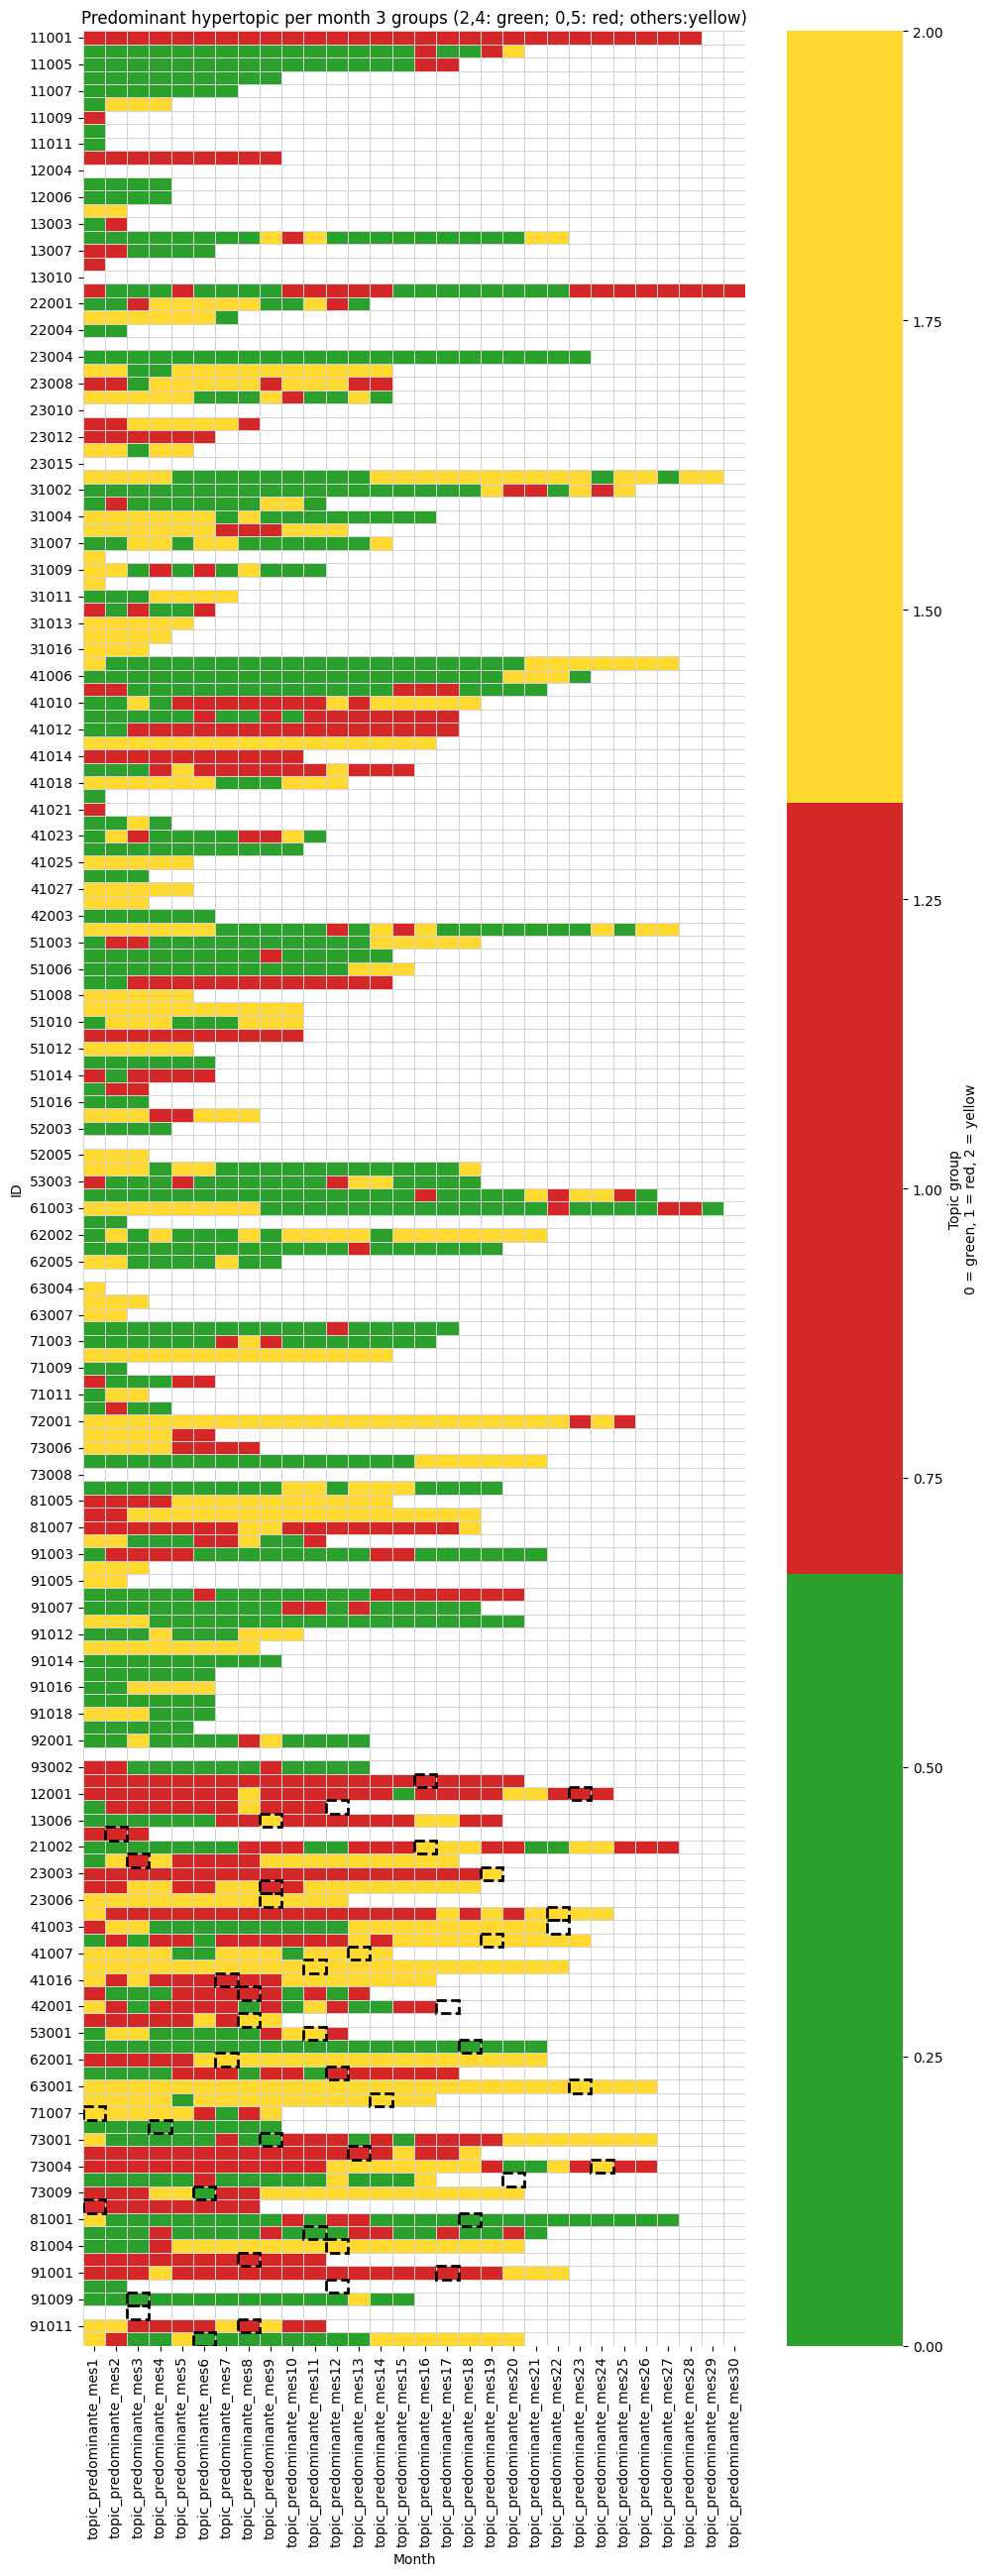

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# -------------------------------------------
# 1 · Copiar el DataFrame limpio
# -------------------------------------------
plot_df_clean = (
    plot_df
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# -------------------------------------------
# 2 · Mapear tópicos → grupos
#   topic 0 → grupo 0 (verde)
#   topic 4 → grupo 1 (rojo)
#   resto   → grupo 2 (amarillo)
# -------------------------------------------
#group_map = {0: 0, 1:1, 2:0, 4: 0,5:1}  # solo mapear explícitos
group_map = {0:1, 2:0,4:0,5:1,1:2,3:2}  # solo mapear explícitos
plot_df_grouped = plot_df_clean.replace(group_map)

# Todo lo que no sea 0 o 1 en group_map se pone como 2
plot_df_grouped = plot_df_grouped.applymap(lambda x: 2 if pd.notna(x) and x not in [0, 1] else x)


# -------------------------------------------
# 3 · Colores para los tres grupos
# -------------------------------------------
group_colors = ['#2ca02c',   # verde (grupo 0)
                '#d62728',   # rojo  (grupo 1)
                '#ffd92f']   # amarillo (grupo 2)
cmap_groups = ListedColormap(group_colors)

# -------------------------------------------
# 4 · Dibujar figura y heatmap
# -------------------------------------------
fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15))

sns.heatmap(
    plot_df_grouped,
    cmap=cmap_groups,
    vmin=0, vmax=2,           # ahora tres valores: 0,1,2
    linewidths=.5, linecolor='lightgray',
    mask=plot_df_grouped.isna(),
    cbar_kws={'label': 'Topic group\n0 = green, 1 = red, 2 = yellow'},
    ax=ax
)

# -------------------------------------------
# 5 · Marcar la celda del evento
# -------------------------------------------
for i, row in ordered_df.iterrows():
    if row['Event'] == 1:
        mes_evento = int(row['t_evento_eb2'] // 30)
        if mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (mes_evento, i), 1, 1,
                fill=False, edgecolor='black', linewidth=2, linestyle='--'
            ))
            # También puedes marcar con estrella si prefieres:
            # ax.text(mes_evento+0.5, i+0.5, '★',
            #         ha='center', va='center', color='black', fontsize=12)

# -------------------------------------------
# 6 · Etiquetas finales
# -------------------------------------------
plt.title("Predominant hypertopic per month 3 groups (2,4: green; 0,5: red; others:yellow)")
plt.xlabel("Month")
plt.ylabel("ID")
plt.tight_layout()
plt.show()



# avance por semana

In [20]:
import ast
from typing import List, Tuple

def get_weekly_topic_evolution(
        df,
        patient_id,
        lda_model,
        dictionary,
        window_size: int = 30,
        step: int = 7
    ) -> Tuple[List[List[float]], List[int]]:
    """
    Devuelve la evolución semanal de tópicos para un paciente.

    • window_size = 30  → cada punto semanal se calcula con los 30 días previos
                          (incluyendo la semana actual).
    • step        = 7   → la ventana se desplaza 7 días en cada iteración.

    Retorna:
        - topic_distributions : lista de distribuciones (una por semana)
        - predominant_topics  : lista de tópicos predominantes (uno por semana)
    """
    # ---- 1. localizar al paciente ----
    row = df[df['id'] == patient_id]
    if row.empty:
        print(f"No se encontró el ID {patient_id}")
        return [], []

    embedding_ids = row.iloc[0]['embedding_ids']
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)

    topic_distributions: List[List[float]] = []
    predominant_topics: List[int] = []

    n = len(embedding_ids)

    # ---- 2. recorrer con ventana deslizante de 30 días y paso 7 ----
    for start in range(0, n - window_size + 1, step):
        window = embedding_ids[start:start + window_size]

        bow = dictionary.doc2bow([str(tok) for tok in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)

        # distribución completa (ordenada por ID de tópico)
        probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(probs)

        # tópico predominante en la ventana
        predominant_topics.append(max(topics, key=lambda x: x[1])[0])

    return topic_distributions, predominant_topics


In [21]:
import pandas as pd
import ast

# --- 1. Obtener todos los IDs únicos ---
patient_ids = df_day['id'].unique()

# --- 2. Diccionario: {id: [topic_pred_sem1, sem2, ...]} ---
topic_blocks_by_patient = {}
max_weeks = 0

for pid in patient_ids:
    _, predominant_topics = get_weekly_topic_evolution(
        df_day, pid, lda_model, dictionary,
        window_size=30, step=7
    )
    topic_blocks_by_patient[pid] = predominant_topics
    max_weeks = max(max_weeks, len(predominant_topics))

# --- 3. Construir tabla resultado ---
rows = []
for pid in patient_ids:
    # Extraer info básica del paciente
    base_info = df_day.loc[df_day['id'] == pid, ['Event', 'fecha_evento', 't_evento_eb2']].iloc[0].to_dict()

    row = {'id': pid, **base_info}

    # Añadir columnas: topic_predominante_semana1, semana2, ...
    topics = topic_blocks_by_patient[pid]
    for i in range(max_weeks):
        colname = f'topic_predominante_semana{i+1}'
        row[colname] = topics[i] if i < len(topics) else pd.NA

    rows.append(row)

# --- 4. Convertir a DataFrame final ---
result_weekly_df = pd.DataFrame(rows)


/tmp/ipykernel_14511/321942658.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df


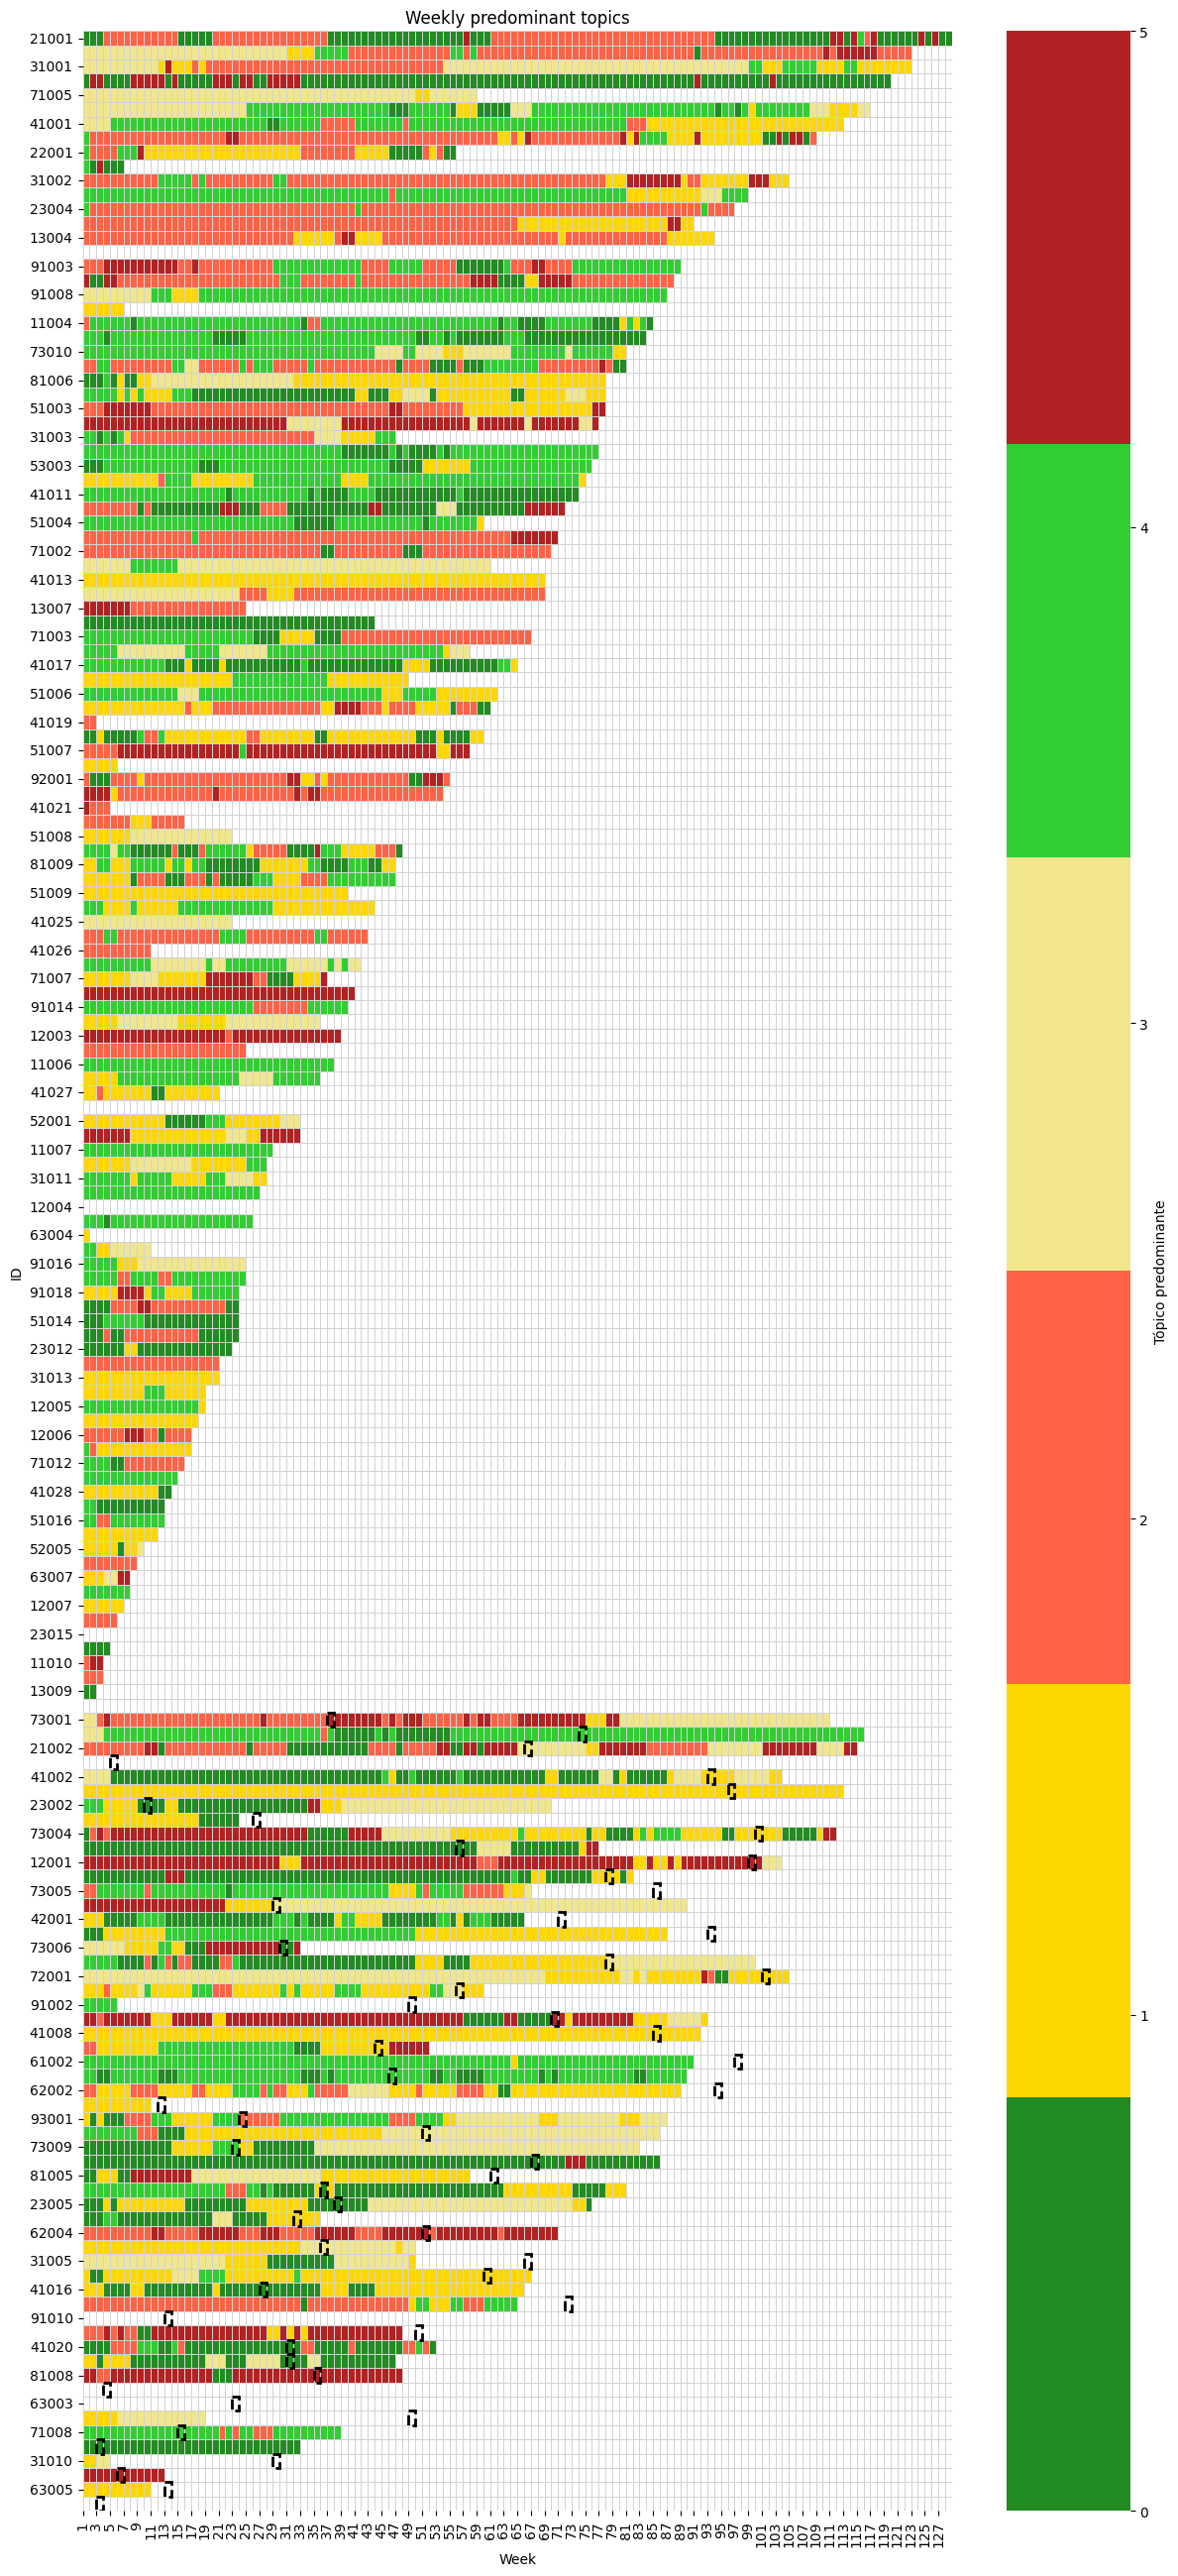

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------------
# 1 · Preparar la matriz para el heatmap
# ------------------------------------------------------------------
# Ordenar: primero sin evento, luego con evento
df_no_event = result_weekly_df[result_weekly_df['Event'] == 0]
df_with_event = result_weekly_df[result_weekly_df['Event'] == 1]
ordered_df = pd.concat([df_no_event, df_with_event], ignore_index=True)

# Seleccionar solo columnas de tópicos por semana
topic_cols = [col for col in ordered_df.columns if col.startswith('topic_predominante_semana')]

# DataFrame para graficar
plot_df = ordered_df[['id'] + topic_cols].set_index('id')

# Reemplazar NA por np.nan y convertir a float
plot_df_clean = (
    plot_df
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors='coerce')
)

# ------------------------------------------------------------------
# 2 · Definir colores por tópico (igual que antes)
# ------------------------------------------------------------------


'''topic_colors = {
    0: "#b22222",  # rojo fuego (topic 0)
    5: "#ff6347",  # rojo tomate (topic 5)

    2: "#228b22",  # verde bosque (topic 2)
    4: "#32cd32",  # verde lima (topic 4)

    1: "#ffd700",  # amarillo dorado (topic 1)
    3: "#f0e68c",  # amarillo khaki (topic 3)
}'''

topic_colors = {
    5: "#b22222",  # rojo fuego (topic 0)
    2: "#ff6347",  # rojo tomate (topic 5)
    #2: "#ffc107",

    0: "#228b22",  # verde bosque (topic 2)
    4: "#32cd32",  # verde lima (topic 4)

    1: "#ffd700",  # amarillo dorado (topic 1)
    3: "#f0e68c",  # amarillo khaki (topic 3)
    
}

color_list = [topic_colors[i] for i in sorted(topic_colors)]
cmap = ListedColormap(color_list)

# ------------------------------------------------------------------
# 3 · Dibujar heatmap
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, len(plot_df_clean) * 0.15))

sns.heatmap(
    plot_df_clean,
    cmap=cmap,
    vmin=0,
    vmax=len(color_list) - 1,
    linewidths=.5,
    linecolor='lightgray',
    cbar_kws={'label': 'Tópico predominante'},
    mask=plot_df_clean.isna(),
    ax=ax
)

# ------------------------------------------------------------------
# 4 · Marcar la semana del evento
# ------------------------------------------------------------------
for i, row in ordered_df.iterrows():
    if row['Event'] == 1:
        semana_evento = int(row['t_evento_eb2'] // 7)  # ← cambio clave
        if semana_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle(
                (semana_evento, i), 1, 1,
                fill=False, edgecolor='black',
                linewidth=2, linestyle='--'
            ))
            # Alternativa: estrella
            # ax.text(semana_evento + 0.5, i + 0.5, '★', ha='center', va='center', color='black', fontsize=12)

# ------------------------------------------------------------------
# 5 · Etiquetas y mostrar
# ------------------------------------------------------------------
# Mostrar una etiqueta por cada semana

# Número total de columnas (semanas)
n_weeks = len(topic_cols)

# Mostrar etiqueta cada 2 semanas (0, 2, 4, …)
xticks = np.arange(0, n_weeks, 2)
ax.set_xticks(xticks)
ax.set_xticklabels([str(i + 1) for i in xticks], rotation=90)  # '1', '3', '5', ...

plt.title("Weekly predominant topics")
plt.xlabel("Week")
plt.ylabel("ID")
plt.tight_layout()
plt.show()


## probability of hypertopic 2&5 per week

/tmp/ipykernel_14511/1616210524.py:72: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df   = (ordered_df[['id'] + week_cols].set_index('id')


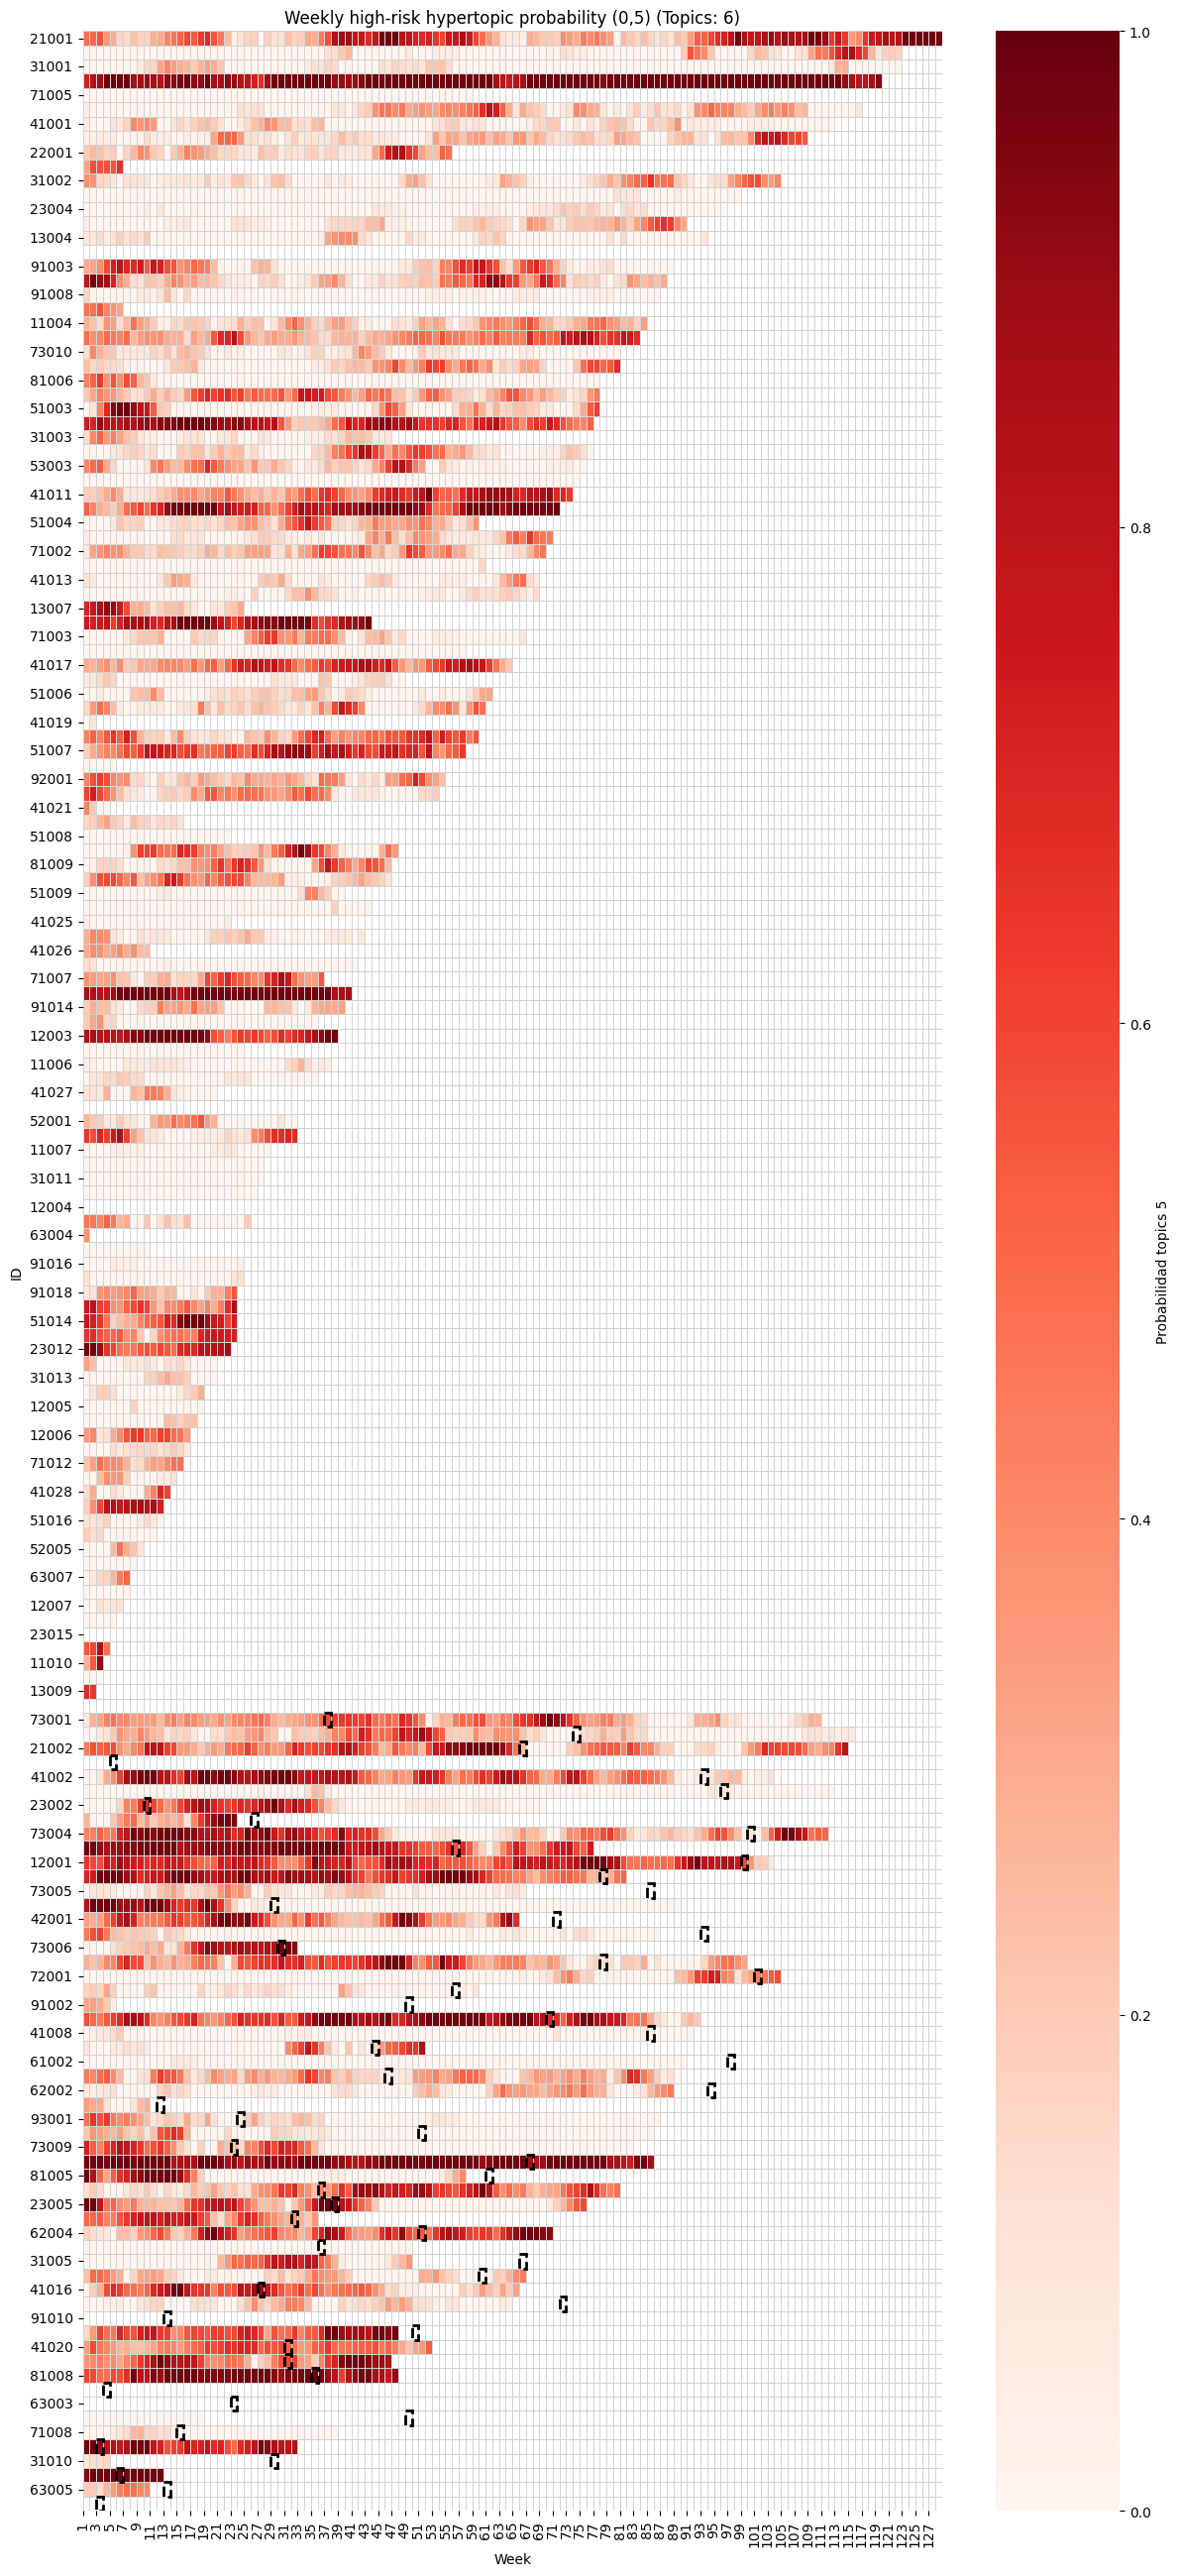

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import ast

# ------------------------------------------------------------------
# 1 · Función auxiliar: prob. de topics 2+5 por cada ventana semanal
# ------------------------------------------------------------------
def weekly_bad_probs(df, patient_id, lda_model, dictionary,
                     window_size=30, step=7, bad_ids=(0,5)):
    """
    Devuelve una lista con p_bad por semana para un paciente.
    p_bad = sumatoria de probabilidades de los topics 'bad_ids'.
    """
    row = df[df['id'] == patient_id]
    if row.empty:
        return []

    emb = row.iloc[0]['embedding_ids']
    if isinstance(emb, str):
        emb = ast.literal_eval(emb)

    p_bad_weeks = []
    for start in range(0, len(emb) - window_size + 1, step):
        window = emb[start:start + window_size]
        bow = dictionary.doc2bow([str(tok) for tok in window])
        probs = dict(lda_model.get_document_topics(bow, minimum_probability=0.0))
        p_bad = sum(probs.get(tid, 0.0) for tid in bad_ids)
        p_bad_weeks.append(p_bad)

    return p_bad_weeks

# ------------------------------------------------------------------
# 2 · Construir tabla paciente × semana con p_bad
# ------------------------------------------------------------------
patient_ids = df_day['id'].unique()
prob_dict = {}
max_weeks = 0

for pid in patient_ids:
    p_bad = weekly_bad_probs(df_day, pid, lda_model, dictionary,bad_ids=(0,5))
    prob_dict[pid] = p_bad
    max_weeks = max(max_weeks, len(p_bad))

rows = []
for pid in patient_ids:
    base_info = df_day.loc[df_day['id'] == pid,
                           ['Event', 'fecha_evento', 't_evento_eb2']].iloc[0].to_dict()
    row = {'id': pid, **base_info}

    probs = prob_dict[pid]
    for i in range(max_weeks):
        col = f'prob_bad_semana{i+1}'
        row[col] = probs[i] if i < len(probs) else pd.NA
    rows.append(row)

prob_weekly_df = pd.DataFrame(rows)
prob_weekly_df.to_csv(module_path+"/data/daily_&_targets/PD_oct2025_eB2_6topics_weeklyTopics_lda100000.csv",index=False)



# ------------------------------------------------------------------
# 3 · Ordenar (sin evento arriba) y preparar matriz para el plot
# ------------------------------------------------------------------
df_no_evt  = prob_weekly_df[prob_weekly_df['Event'] == 0]
df_with_evt= prob_weekly_df[prob_weekly_df['Event'] == 1]
ordered_df = pd.concat([df_no_evt, df_with_evt], ignore_index=True)

week_cols = [c for c in ordered_df.columns if c.startswith('prob_bad_semana')]
plot_df   = (ordered_df[['id'] + week_cols].set_index('id')
             .replace({pd.NA: np.nan}).astype(float))

# ------------------------------------------------------------------
# 4 · Heat-map de p_bad (0–1).  Colormap: blanco→rojo.
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, len(plot_df) * 0.15))

sns.heatmap(
    plot_df,
    cmap='Reds',
    vmin=0, vmax=1,
    linewidths=.5, linecolor='lightgray',
    cbar_kws={'label': 'Probabilidad topics 5'},
    mask=plot_df.isna(),
    ax=ax
)

# ------------------------------------------------------------------
# 5 · Resaltar la semana del evento
# ------------------------------------------------------------------
for i, row in ordered_df.iterrows():
    if row['Event'] == 1:
        wk_evt = int(row['t_evento_eb2'] // 7)
        if wk_evt < len(week_cols):
            ax.add_patch(plt.Rectangle(
                (wk_evt, i), 1, 1,
                fill=False, edgecolor='black', linewidth=2, linestyle='--'
            ))

# mostrar etiqueta “1,3,5…” cada 2 semanas
n_weeks = len(week_cols)
ticks = np.arange(0, n_weeks, 2)
ax.set_xticks(ticks)
ax.set_xticklabels([str(i+1) for i in ticks], rotation=90)

plt.title(f"Weekly high-risk hypertopic probability (0,5) (Topics: {n_topics})")
plt.xlabel("Week")
plt.ylabel("ID")
plt.tight_layout()
plt.show()


# Evolution per cohort

In [114]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

def plot_heatmaps_by_cohort(ordered_df, topic_cols, topic_colors_by_cohort, save_dir=None):
    """
    Genera un heatmap de tópicos predominantes por cohorte.
    
    Parameters
    ----------
    ordered_df : pd.DataFrame
        DataFrame con columnas 'id', 'Event', 't_evento_eb2', 'Cohorte' y columnas topic_predominante_mesN.
    topic_cols : list
        Lista de columnas de tópicos predominantes.
    topic_colors_by_cohort : dict
        Diccionario {cohorte: {topic_id: hexcolor}}.
    save_dir : str or None
        Si se da, guarda cada plot en esa carpeta.
    """
    cohorts = ordered_df['Cohorte'].unique()
    
    for cohort in cohorts:
        if cohort not in topic_colors_by_cohort:
            raise KeyError(f"No color map defined for cohort '{cohort}'")

        df_cohort = ordered_df[ordered_df['Cohorte'] == cohort].reset_index(drop=True)
        plot_df = df_cohort[['id'] + topic_cols].set_index('id')
        plot_df_clean = (
            plot_df
            .replace({pd.NA: np.nan})
            .apply(pd.to_numeric, errors='coerce')
        )

        # Colores específicos de este cohorte
        topic_colors = topic_colors_by_cohort[cohort]
        color_list = [topic_colors[i] for i in sorted(topic_colors)]
        cmap = ListedColormap(color_list)

        # Dibujar heatmap
        fig, ax = plt.subplots(figsize=(12, len(plot_df_clean) * 0.15))
        sns.heatmap(
            plot_df_clean,
            cmap=cmap,
            vmin=0, vmax=len(color_list) - 1,
            linewidths=.5, linecolor='lightgray',
            cbar_kws={'label': 'Predominant Topic'},
            mask=plot_df_clean.isna(),
            ax=ax
        )

        # Marcar evento
        for i, row in df_cohort.iterrows():
            if row['Event'] == 1:
                mes_evento = int(row['t_evento_eb2'] // 30)
                if mes_evento < len(topic_cols):
                    ax.add_patch(plt.Rectangle(
                        (mes_evento, i), 1, 1,
                        fill=False, edgecolor='black',
                        linewidth=2, linestyle='--'
                    ))

        # Etiquetas
        plt.title(f"{cohort}: Predominant topics per month")
        plt.xlabel("Month")
        plt.ylabel("Patient ID")
        plt.tight_layout()

        # Guardar si se pide
        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"heatmap_{cohort}.png")
            plt.savefig(save_path, dpi=300)
            print(f"Plot saved at {save_path}")

        plt.show()


Plot saved at /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/topic_plots/heatmap_Breast.png


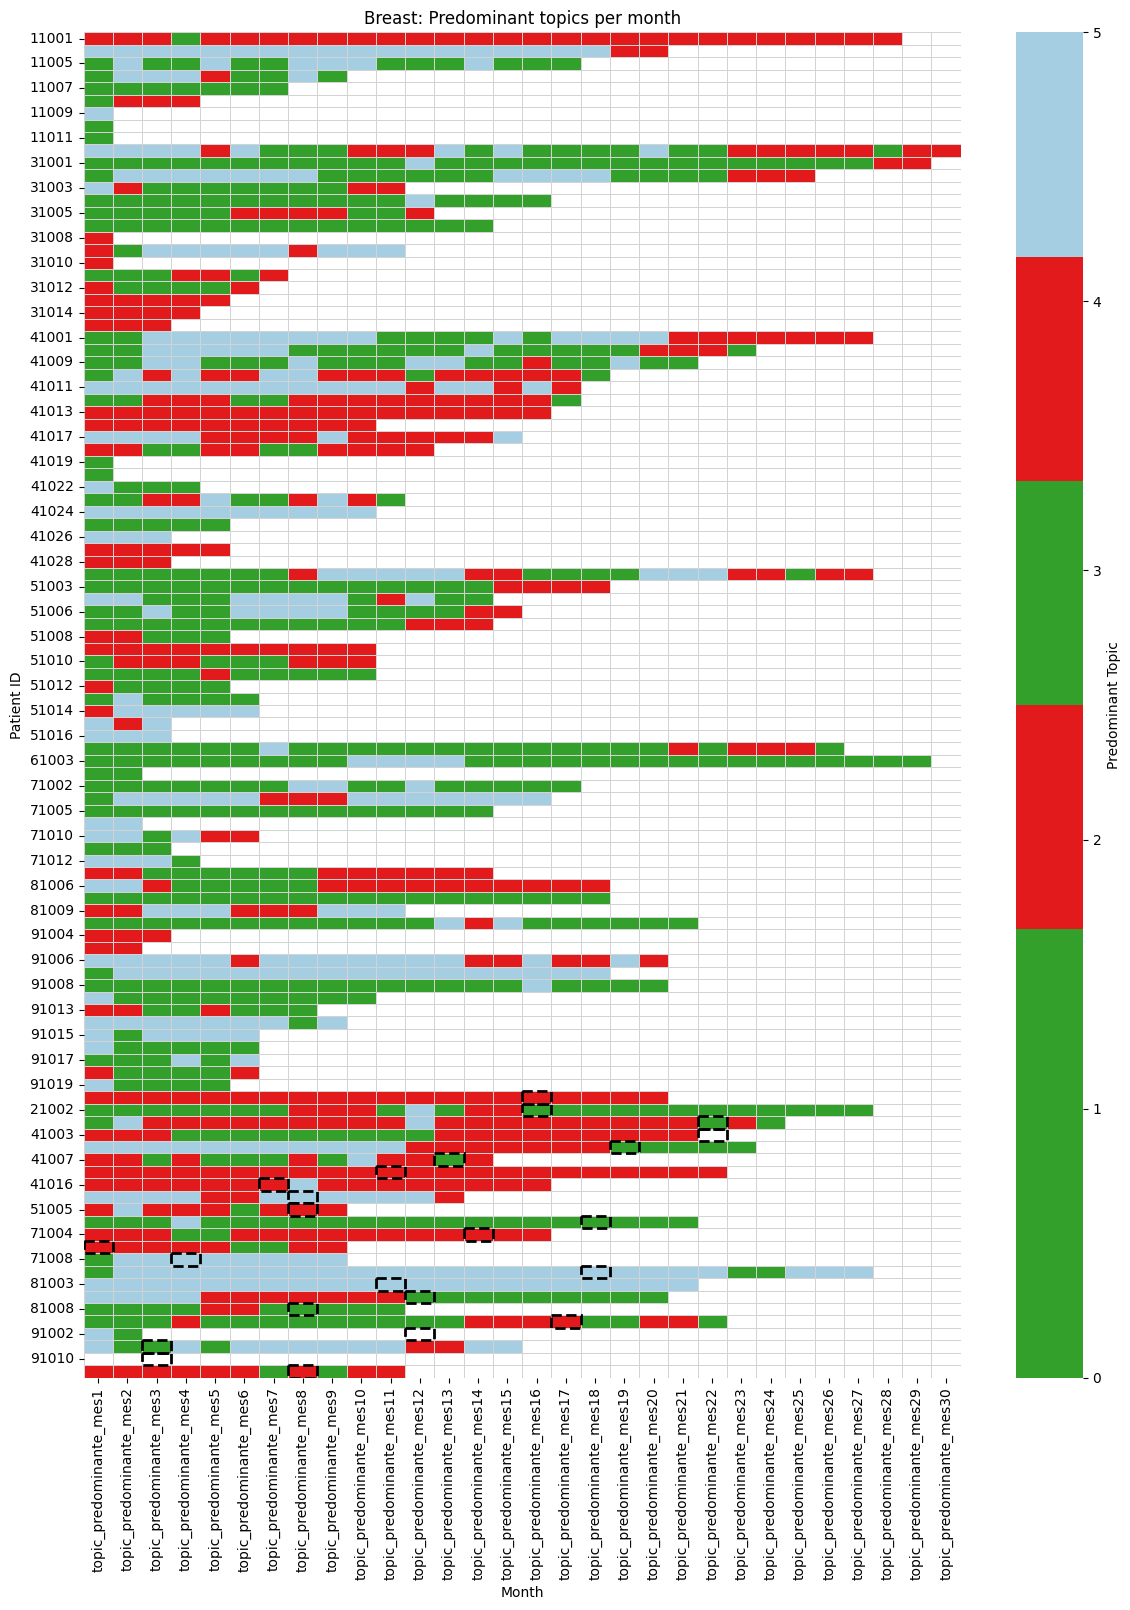

Plot saved at /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/topic_plots/heatmap_Colorectal.png


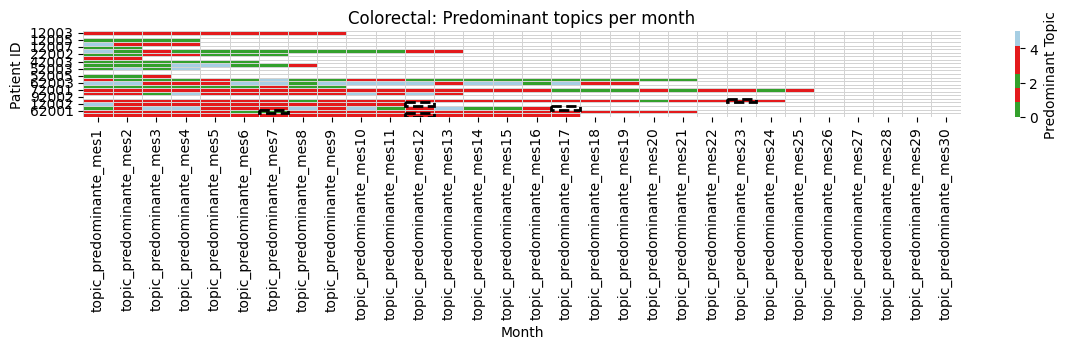

Plot saved at /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/topic_plots/heatmap_Lung.png


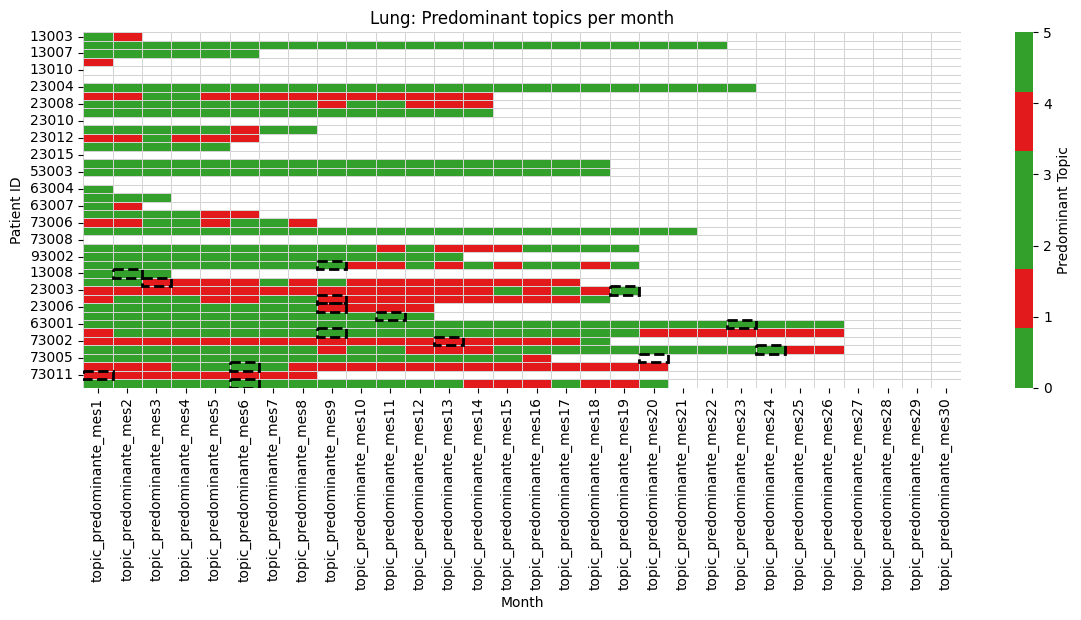

In [116]:
ordered_df=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_august_2025s_eB2_a0_6topics100000_MonthPredom.csv")


# Asegurar que id está en ambos dataframes con el mismo tipo
ordered_df['id'] = ordered_df['id'].astype(int)
df_day['id'] = df_day['id'].astype(int)

# Hacer merge para añadir la cohorte
ordered_df = ordered_df.merge(
    df_day[['id', 'Cohorte']],  # solo traemos Cohorte y la clave id
    on='id',
    how='left'
)


topic_colors_by_cohort = {
    'Breast': {
        0: '#33a02c',  #  verde medio
        1: '#33a02c',  #  warm yellow-orange
        2: '#e31a1c',  # rojo medio
        3: '#33a02c',  # soft pastel yellow
        4: '#e31a1c',  # rojo oscuro    ← “malo”
        5: '#a6cee3',  # azul claro
    },
    'Lung': {
        0: '#33a02c',  #  verde medio
        1: '#e31a1c',  #  warm yellow-orange
        2: '#33a02c',  # rojo medio  
        3: '#33a02c',  # soft pastel yellow
        4: '#e31a1c',  # rojo oscuro    ← “malo”
        5: '#33a02c',  # azul claro
    },
    'Colorectal': {
        0: '#33a02c',  #  verde medio
        1: '#e31a1c',  #  warm yellow-orange
        2: '#33a02c',  # pastel yellow  
        3: '#e31a1c',  # rojo  medio
        4: '#e31a1c',  # rojo oscuro    ← “malo”
        5: '#a6cee3',  # azul claro
    }
}


{
    0: '#33a02c',  #  verde medio
    1: '#fdae61',  #  warm yellow-orange
    2: '#1f78b4',  # azul medio
    3: '#ffed6f',  # soft pastel yellow
    4: '#b30000',  # rojo oscuro    ← “malo”
    5: '#a6cee3',  # azul claro
}

plot_heatmaps_by_cohort(
    ordered_df,
    topic_cols=topic_cols,
    topic_colors_by_cohort=topic_colors_by_cohort,
    save_dir=os.path.join(module_path, "2nd_phase", "results", "topic_plots")
)


## probabilities

In [132]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

def weekly_bad_probs(df, patient_id, lda_model, dictionary,
                     window_size=30, step=7, bad_ids=(2, 5)):
    """
    Calcula la lista de probabilidades semanales p_bad para un paciente.
    p_bad = suma de probabilidades de topics 'bad_ids'.
    """
    row = df[df['id'] == patient_id]
    if row.empty:
        return []

    emb = row.iloc[0]['embedding_ids']
    if isinstance(emb, str):
        emb = ast.literal_eval(emb)

    p_bad_weeks = []
    for start in range(0, len(emb) - window_size + 1, step):
        window = emb[start:start + window_size]
        bow = dictionary.doc2bow([str(tok) for tok in window])
        probs = dict(lda_model.get_document_topics(bow, minimum_probability=0.0))
        p_bad = sum(probs.get(tid, 0.0) for tid in bad_ids)
        p_bad_weeks.append(p_bad)

    return p_bad_weeks


def plot_weekly_bad_probs_by_cohort(df_day, lda_model, dictionary,
                                    bad_topics_by_cohort,
                                    window_size=30, step=7,
                                    save_dir=None):
    """
    Calcula y plotea la prob. semanal de tópicos malos, separada por cohorte.
    - Crea columnas prob_bad_semanaN según los bad_topics de cada cohorte.
    - Genera un heatmap por cohorte.
    """
    patient_ids = df_day['id'].unique()
    rows = []
    max_weeks = 0

    # ---- 1. Calcular p_bad para cada paciente según su cohorte ----
    for pid in patient_ids:
        base_info = df_day.loc[df_day['id'] == pid,
                               ['Event', 't_evento_eb2', 'Cohorte']].iloc[0].to_dict()
        cohort = base_info['Cohorte']
        bad_ids = bad_topics_by_cohort.get(cohort, ())

        if not bad_ids:
            print(f"⚠️ Cohorte '{cohort}' no tiene bad_topics definidos, se ignora paciente {pid}.")
            continue

        probs = weekly_bad_probs(df_day, pid, lda_model, dictionary,
                                 window_size=window_size, step=step, bad_ids=bad_ids)
        max_weeks = max(max_weeks, len(probs))

        row = {'id': pid, **base_info}
        for i in range(max_weeks):
            col = f'prob_bad_semana{i+1}'
            row[col] = probs[i] if i < len(probs) else pd.NA
        rows.append(row)

    prob_weekly_df = pd.DataFrame(rows)

    # ---- 2. Ordenar pacientes (sin evento arriba) ----
    df_no_evt = prob_weekly_df[prob_weekly_df['Event'] == 0]
    df_with_evt = prob_weekly_df[prob_weekly_df['Event'] == 1]
    ordered_df = pd.concat([df_no_evt, df_with_evt], ignore_index=True)

    week_cols = [c for c in ordered_df.columns if c.startswith('prob_bad_semana')]

    # ---- 3. Dibujar un heatmap por cohorte ----
    for cohort in ordered_df['Cohorte'].unique():
        df_cohort = ordered_df[ordered_df['Cohorte'] == cohort].reset_index(drop=True)
        plot_df = (df_cohort[['id'] + week_cols]
                   .set_index('id')
                   .replace({pd.NA: np.nan})
                   .astype(float))

        fig, ax = plt.subplots(figsize=(12, len(plot_df) * 0.15))

        sns.heatmap(
            plot_df,
            cmap='Reds',
            vmin=0, vmax=1,
            linewidths=.5, linecolor='lightgray',
            cbar_kws={'label': f"Probability of bad topics {bad_topics_by_cohort[cohort]}"},
            mask=plot_df.isna(),
            ax=ax
        )

        # marcar evento
        for i, row in df_cohort.iterrows():
            if row['Event'] == 1:
                wk_evt = int(row['t_evento_eb2'] // step)
                if wk_evt < len(week_cols):
                    ax.add_patch(plt.Rectangle(
                        (wk_evt, i), 1, 1,
                        fill=False, edgecolor='black',
                        linewidth=2, linestyle='--'
                    ))

        # ticks cada 2 semanas
        n_weeks = len(week_cols)
        ticks = np.arange(0, n_weeks, 2)
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(i+1) for i in ticks], rotation=90)

        plt.title(f"{cohort}: Probability of bad topics {bad_topics_by_cohort[cohort]} per week")
        plt.xlabel("Week")
        plt.ylabel("Patient ID")
        plt.tight_layout()

        # guardar si se pide
        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"weekly_bad_probs_{cohort}.png")
            plt.savefig(save_path, dpi=300)
            print(f"Plot saved at: {save_path}")

        plt.show()

    return prob_weekly_df


In [133]:
df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_august_2025s_eB2_TopicsClusters_a0_6topics100000_PrimerasFechas.csv")


/tmp/ipykernel_2920142/3683375795.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df = (df_cohort[['id'] + week_cols]


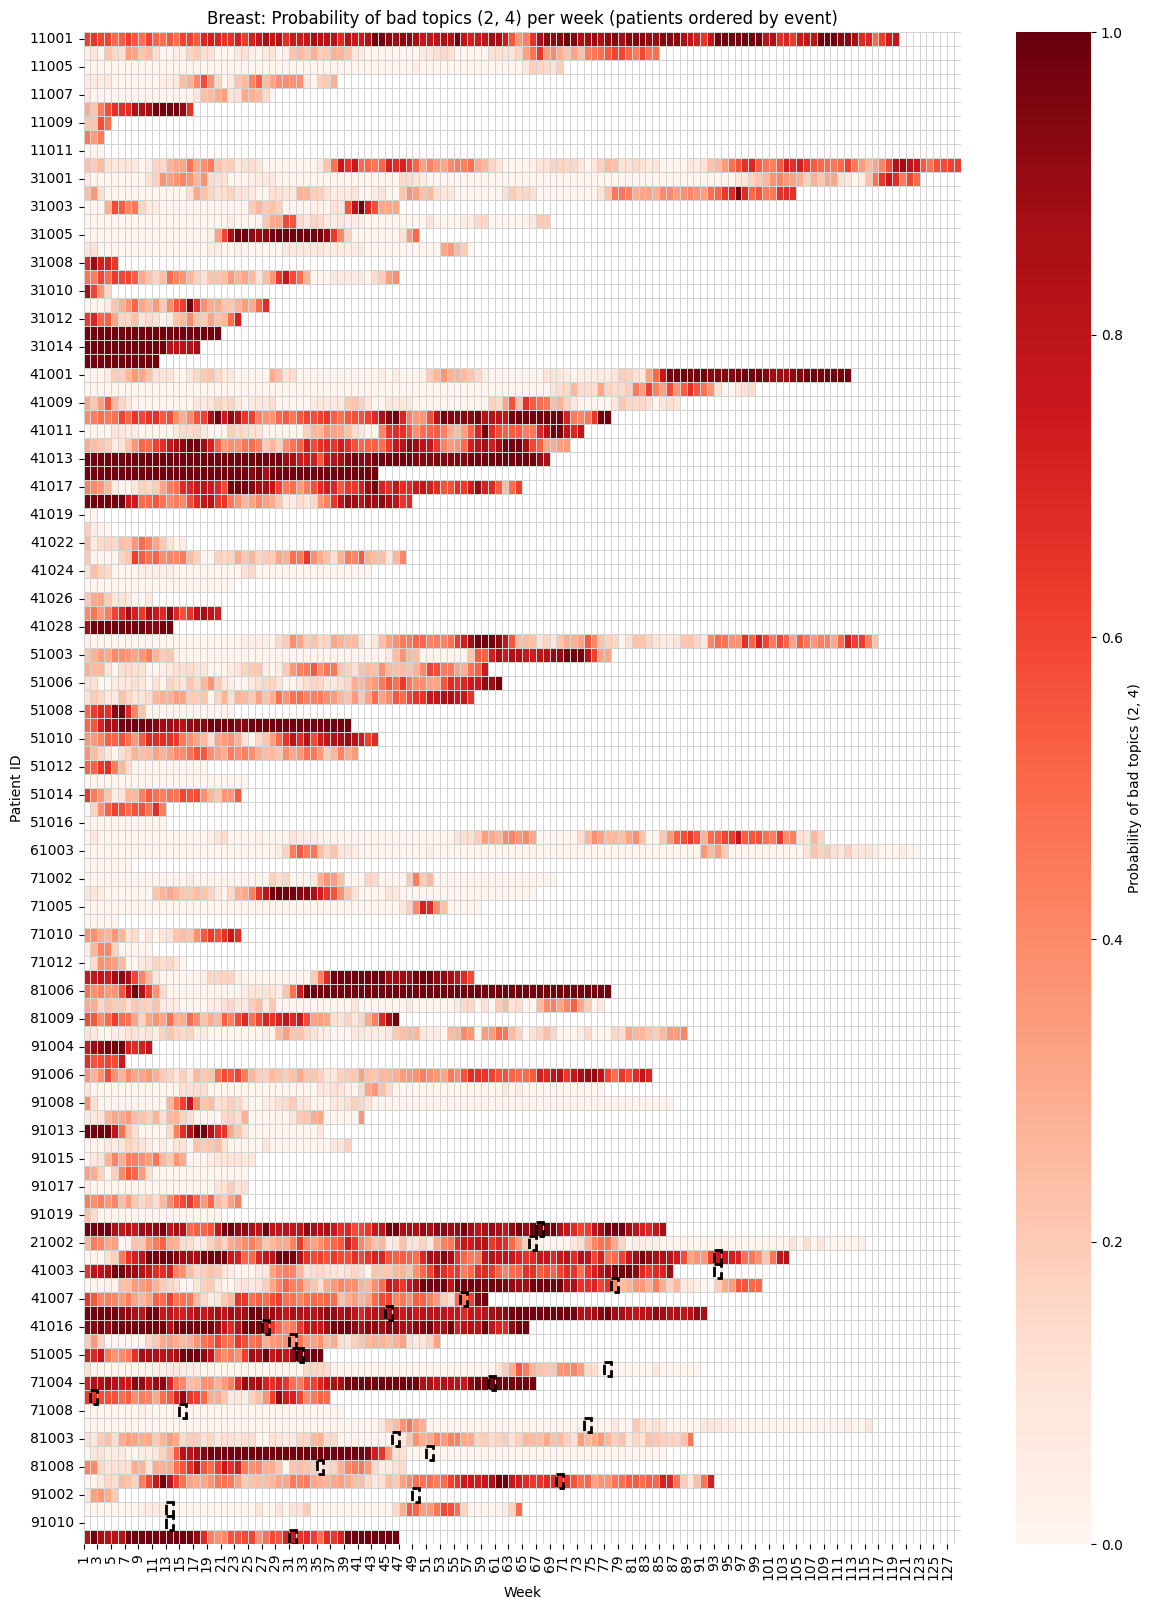

/tmp/ipykernel_2920142/3683375795.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df = (df_cohort[['id'] + week_cols]


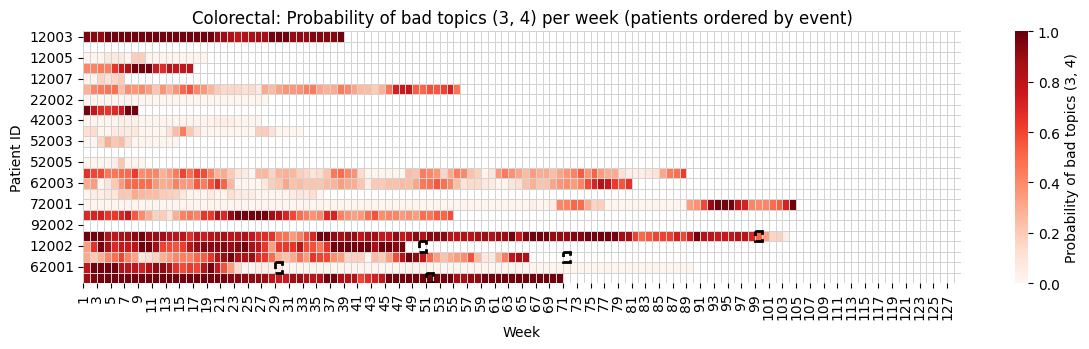

/tmp/ipykernel_2920142/3683375795.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df = (df_cohort[['id'] + week_cols]


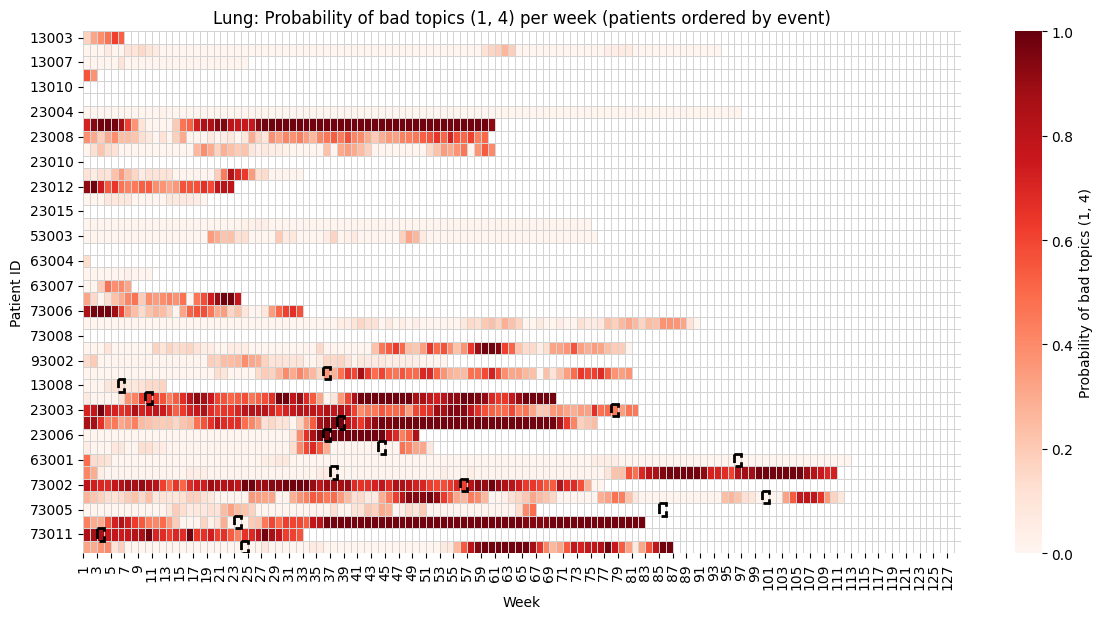

,id,Event,t_evento_eb2,Cohorte,prob_bad_semana1,prob_bad_semana2,prob_bad_semana3,prob_bad_semana4,prob_bad_semana5,prob_bad_semana6,...,prob_bad_semana119,prob_bad_semana120,prob_bad_semana121,prob_bad_semana122,prob_bad_semana123,prob_bad_semana124,prob_bad_semana125,prob_bad_semana126,prob_bad_semana127,prob_bad_semana128
0,11001,0,NaN,Breast,0.610154,0.646715,0.598237,0.604103,0.498316,0.540145,...,0.780268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11003,1,463.0,Breast,0.978426,0.978388,0.978366,0.978352,0.843825,0.784339,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11004,0,NaN,Breast,0.053268,0.113087,0.01086,0.214292,0.15282,0.136608,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11005,0,NaN,Breast,0.010788,0.010763,0.010765,0.010768,0.010769,0.010791,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11006,0,NaN,Breast,0.069975,0.065766,0.057936,0.085744,0.010822,0.010817,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,91019,0,NaN,Breast,0.237821,0.143033,0.010795,0.01079,0.010765,0.010768,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
170,92001,0,NaN,Colorectal,0.695104,0.708218,0.722921,0.641935,0.640183,0.693585,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
171,92002,0,NaN,Colorectal,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
172,93001,1,164.0,Lung,0.322025,0.304377,0.3661,0.398945,0.103886,0.183597,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [135]:
bad_topics_by_cohort = {
    'Breast': (2, 4),      # malos en Breast
    'Lung': (1,4),        # malos en Lung
    'Colorectal': (3, 4)   # malos en Colorectal
}



plot_weekly_bad_probs_by_cohort(df_day, lda_model, dictionary,
                                    bad_topics_by_cohort,
                                    window_size=30, step=7,
                                    save_dir=None)
    



# BBDD lda diario para CPD

In [ ]:
import ast
import pandas as pd

def _ensure_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return list(x)

def _lda_probs_and_pred_topic(window_ids, lda_model, dictionary, num_topics=None):
    # window_ids: lista de embedding_ids (ints)
    bow = dictionary.doc2bow([str(tok) for tok in window_ids])
    topics = lda_model.get_document_topics(bow, minimum_probability=0.0)

    # probs en orden fijo por topic_id
    if num_topics is None:
        num_topics = lda_model.num_topics

    probs = [0.0] * num_topics
    for tid, p in topics:
        probs[int(tid)] = float(p)

    pred_topic = int(max(topics, key=lambda x: x[1])[0]) if topics else pd.NA
    return probs, pred_topic

def add_daily_lda_sequences_to_df_day(
    df_day: pd.DataFrame,
    lda_model,
    dictionary,
    window_size: int = 30,
    id_col: str = "id",
    emb_col: str = "embedding_ids",
    keep_cols=None,
):
    """
    Devuelve un DF con 1 fila por paciente (id), conservando columnas base y añadiendo:
      - 'lda_topic_seq': lista (len = nº días) con tópico predominante por día
      - 'lda_topic_prob_seq': lista (len = nº días) con distribución probs por día (lista de len=num_topics)

    Lógica por día d:
      - si d < window_size: usa embeddings[0 : d+1] (acumulativo)
      - si d >= window_size: usa embeddings[d-window_size+1 : d+1] (ventana deslizante)
    """
    if keep_cols is None:
        keep_cols = [
            "Fecha_entrada_HDM",
            "Evento PD",
            "Tiempo Obs Final",
            "diferencia",
            "Evento PD diff",
            "early PD",
        ]

    num_topics = lda_model.num_topics

    rows = []
    for _, r in df_day.iterrows():
        pid = r[id_col]
        emb = _ensure_list(r[emb_col])
        n = len(emb)

        topic_seq = []
        prob_seq = []

        for d in range(n):
            if d < window_size:
                window = emb[: d + 1]  # acumulativo
            else:
                window = emb[d - window_size + 1 : d + 1]  # rolling 30

            probs, pred = _lda_probs_and_pred_topic(window, lda_model, dictionary, num_topics=num_topics)
            topic_seq.append(pred)
            prob_seq.append(probs)

        base = {c: r[c] for c in ([id_col, emb_col] + keep_cols) if c in df_day.columns}
        base["lda_topic_seq"] = topic_seq
        base["lda_topic_prob_seq"] = prob_seq
        rows.append(base)

    return pd.DataFrame(rows)

# --- USO ---
# df_day = pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv")
# lda_model = LdaModel.load(...)
# dictionary = corpora.Dictionary.load(...)

df_day_lda_seq = add_daily_lda_sequences_to_df_day(
    df_day,
    lda_model,
    dictionary,
    window_size=30,
    id_col="id",
    emb_col="embedding_ids",
    keep_cols=["Fecha_entrada_HDM","Evento PD","Tiempo Obs Final","diferencia","Evento PD diff","early PD"],
)

df_day_lda_seq.head()

,id,embedding_ids,Fecha_entrada_HDM,Evento PD,Tiempo Obs Final,diferencia,Evento PD diff,early PD,lda_topic_seq,lda_topic_prob_seq
0,11001,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...",2023-04-19,0,876,0.0,876.0,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, ...","[[0.08333440870046616, 0.5819708108901978, 0.0..."
1,11003,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...",2023-12-05,1,357,8.0,349.0,0,"[3, 3, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[[0.0833367332816124, 0.08353725075721741, 0.0..."
2,11004,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...",2023-12-20,0,631,0.0,631.0,0,"[2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[[0.08333402872085571, 0.08361563831567764, 0...."
3,11005,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...",2024-03-27,0,533,0.0,533.0,0,"[2, 2, 5, 5, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[0.0833364799618721, 0.08333642780780792, 0.5..."
4,11006,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...",2024-11-20,0,295,0.0,295.0,0,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[[0.08334944397211075, 0.08334406465291977, 0...."


In [ ]:

'''df_day_lda_seq = df_day_lda_seq.rename(columns={
    "Evento PD diff": "t_event_eb2",
    "embedding_ids": "profie_seq",
})
df_day_lda_seq = df_day_lda_seq.drop(columns=["early PD", "diferencia"], errors="ignore")
'''
# reordenar columnas (poniendo primero las que quieres)
df_day_lda_seq = df_day_lda_seq.drop(columns=["Fecha_entrada_HDM", "Tiempo Obs Final"], errors="ignore")
order = ["id", "profie_seq", "lda_topic_seq", "lda_topic_prob_seq", "Evento PD", "t_event_eb2"]

# si alguna no existe, la ignora
cols = [c for c in order if c in df_day_lda_seq.columns] + [c for c in df_day_lda_seq.columns if c not in order]
df_day_lda_seq = df_day_lda_seq[cols].copy()
df_day_lda_seq.to_csv(module_path + "/data/daily_&_targets/PD_dic_2025s_profiles_topic_seqs.csv", index=False)


In [19]:
df_day_lda_seq

,id,profie_seq,lda_topic_seq,lda_topic_prob_seq,Evento PD,t_event_eb2
0,11001,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, ...","[[0.08333440870046616, 0.5819708108901978, 0.0...",0,876.0
1,11003,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...","[3, 3, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[[0.0833367332816124, 0.08353725075721741, 0.0...",1,349.0
2,11004,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...","[2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[[0.08333402872085571, 0.08361563831567764, 0....",0,631.0
3,11005,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...","[2, 2, 5, 5, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[0.0833364799618721, 0.08333642780780792, 0.5...",0,533.0
4,11006,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[[0.08334944397211075, 0.08334406465291977, 0....",0,295.0
...,...,...,...,...,...,...
170,91019,"[248, 168, 66, 8, 76, 72, 224, 243, 78, 40, 40...","[4, 4, 4, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, ...","[[0.0833343043923378, 0.0833342894911766, 0.08...",0,183.0
171,92001,"[141, 81, 81, 61, 229, 196, 122, 236, 81, 81, ...","[2, 2, 2, 2, 2, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, ...","[[0.08333592116832733, 0.08333587646484375, 0....",1,448.0
172,92002,"[24, 117, 165, 246, 250, 220, 45, 188, 85, 76,...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[[0.08333376795053482, 0.08333376049995422, 0....",1,24.0
173,93001,"[107, 77, 178, 48, 28, 1, 31, 109, 213, 136, 1...","[4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...","[[0.0838366150856018, 0.0833338052034378, 0.08...",1,159.0


In [17]:
import pandas as pd
import ast

def _as_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return list(x)

df = df_day_lda_seq.copy()  # tu tabla actual

# longitudes
df["len_profile_seq"] = df["profie_seq"].apply(lambda x: len(_as_list(x)))
df["len_lda_topic_seq"] = df["lda_topic_seq"].apply(lambda x: len(_as_list(x)))
df["len_lda_prob_seq"]  = df["lda_topic_prob_seq"].apply(lambda x: len(_as_list(x)))

# quedarnos solo con los que tienen evento
tabla_evento = (
    df[df["Evento PD"] != 0]
    .assign(t_event_eb2=pd.to_numeric(df["t_event_eb2"], errors="coerce"))
    [["id","Evento PD","t_event_eb2","len_profile_seq","len_lda_topic_seq","len_lda_prob_seq",
      "profie_seq","lda_topic_seq","lda_topic_prob_seq"]]
    .reset_index(drop=True)
)

def shape_prob_seq(prob_seq):
    if prob_seq is None or len(prob_seq) == 0:
        return (0, 0)
    return (len(prob_seq), len(prob_seq[0]))
df["shape_lda_prob_seq"] = df["lda_topic_prob_seq"].apply(shape_prob_seq)
# si además quieres separar en 2 columnas numéricas:
df["n_dias"] = df["shape_lda_prob_seq"].apply(lambda x: x[0])
df["n_topics"] = df["shape_lda_prob_seq"].apply(lambda x: x[1])
tabla_evento = df[df["Evento PD"] != 0][["id","Evento PD","t_event_eb2","len_profile_seq","len_lda_topic_seq","shape_lda_prob_seq"]]


tabla_evento.head()

,id,Evento PD,t_event_eb2,len_profile_seq,len_lda_topic_seq,shape_lda_prob_seq
1,11003,1,349.0,350,350,"(350, 6)"
10,12001,1,362.0,363,363,"(363, 6)"
11,12002,1,137.0,138,138,"(138, 6)"
19,13006,1,154.0,155,155,"(155, 6)"
21,13008,1,37.0,38,38,"(38, 6)"
